# EDA — E3 Intraday Strategy (LSTM Ensemble, 30 min)

Exploratory data analysis for the short-term intraday strategy.

**Tickers**: SPY, AAPL, NVDA, QQQ  
**Frequency**: 5-minute bars  
**Horizon**: 6 bars (30 min)  
**Lookback**: 96 bars (8 hours ~ 1 trading day)  
**Model**: LSTM Ensemble (3 members)  
**Features**: 17 intraday indicators  
**Data**: ~100K bars/ticker (~2 years via Alpaca)

**Key differences vs E1/E2 (daily):**
- Returns ~100x smaller (0.01-0.1% vs 1-10%)
- Intraday seasonality (U-shape in volume, open/close spikes)
- Many more samples (~100K vs ~2.5K) -> greater statistical power
- Relatively higher transaction costs (20 bps round-trip vs 10 bps)


## 0. Setup

In [4]:
import sys
from pathlib import Path

# Add the project root to the path so modules under src/ can be imported.
ROOT = Path("../..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# --- Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- Project imports ---
from src.utils import load_yaml, project_root
from src.e3.intraday_data import load_ohlcv_csv
from src.e3.build_features import compute_intraday_features, make_target_return

# --- Plot style ---
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (14, 5)

print(f"Project root: {project_root()}")


Project root: /Users/sebastiancarreras/Documents/Education/Posgrado_AI_FIUBA/proyecto_final/trading_predict


In [5]:
# --- Load the central configuration ---
cfg = load_yaml(project_root() / "src" / "config" / "base.yaml")

E3_TICKERS = cfg["universe"]["tickers_by_strategy"]["e3_intraday"]
E3_CFG = cfg["strategies"]["e3_intraday"]
HORIZON_BARS = E3_CFG["horizon_bars"]     # 6 bars = 30 min
LOOKBACK_BARS = E3_CFG["lookback_bars"]   # 96 bars = 8 hours ~ 1 trading day
ROUND_TRIP_BPS = cfg["costs"]["intraday_round_trip_bps"]

print(f"Tickers: {E3_TICKERS}")
print(f"Horizon: {HORIZON_BARS} bars ({HORIZON_BARS * 5} min)")
print(f"Lookback: {LOOKBACK_BARS} bars ({LOOKBACK_BARS * 5 / 60:.1f} hours)")
print(f"Costs: {ROUND_TRIP_BPS} bps round-trip")


Tickers: ['SPY', 'AAPL', 'NVDA', 'QQQ']
Horizonte: 6 barras (30 min)
Lookback: 96 barras (8.0 horas)
Costos: 20 bps round-trip


In [6]:
# --- Load frozen 5-min OHLCV data for the EDA (reproducible snapshot) ---
# Goal: make the EDA 100% reproducible across runs.
# Rule: the local snapshot is created ONCE and everything reads from it afterwards.

import hashlib
import json as _json
from datetime import datetime, timezone

source_raw_dir = project_root() / "data" / "raw" / "intraday"
snapshot_root = project_root() / "data" / "snapshots" / "e3_intraday_eda_v1"
manifest_path = snapshot_root / "manifest.json"

def _sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

# Create the snapshot only if it does not exist. Once created it stays fixed for the EDA.
if not snapshot_root.exists():
    snapshot_root.mkdir(parents=True, exist_ok=True)
    print(f"[SNAPSHOT] Creating reproducible snapshot at: {snapshot_root}")

    file_records = []
    for ticker in E3_TICKERS:
        src = source_raw_dir / f"{ticker}_5m.csv"
        dst = snapshot_root / f"{ticker}_5m.csv"

        if not src.exists():
            raise FileNotFoundError(f"No source CSV for {ticker}: {src}")

        import shutil
        shutil.copy2(src, dst)

        df_tmp = load_ohlcv_csv(dst)
        file_records.append({
            "ticker": ticker,
            "file": dst.name,
            "rows": int(len(df_tmp)),
            "start": str(df_tmp.index.min()),
            "end": str(df_tmp.index.max()),
            "sha256": _sha256_file(dst),
        })

    manifest = {
        "snapshot_name": "e3_intraday_eda_v1",
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "strategy": "e3_intraday",
        "horizon_bars": HORIZON_BARS,
        "lookback_bars": LOOKBACK_BARS,
        "interval": "5m",
        "tickers": E3_TICKERS,
        "files": file_records,
    }
    manifest_path.write_text(_json.dumps(manifest, indent=2), encoding="utf-8")
    print(f"[SNAPSHOT] Manifest saved: {manifest_path}")
else:
    print(f"[SNAPSHOT] Using existing snapshot: {snapshot_root}")
    if manifest_path.exists():
        print(f"[SNAPSHOT] Manifest: {manifest_path}")
    else:
        print("[SNAPSHOT] Warning: manifest.json not found")

# ALWAYS load from the snapshot (fixed dataset).
data = {}
for ticker in E3_TICKERS:
    path = snapshot_root / f"{ticker}_5m.csv"
    if path.exists():
        data[ticker] = load_ohlcv_csv(path)
        print(f"  {ticker}: {len(data[ticker]):,} bars  ({data[ticker].index[0]} → {data[ticker].index[-1]})")
    else:
        raise FileNotFoundError(f"Missing snapshot file for {ticker}: {path}")

print(f"\nTickers loaded from snapshot: {len(data)}/{len(E3_TICKERS)}")


[SNAPSHOT] Usando snapshot existente: /Users/sebastiancarreras/Documents/Education/Posgrado_AI_FIUBA/proyecto_final/trading_predict/data/snapshots/e3_intraday_eda_v1
[SNAPSHOT] Manifest: /Users/sebastiancarreras/Documents/Education/Posgrado_AI_FIUBA/proyecto_final/trading_predict/data/snapshots/e3_intraday_eda_v1/manifest.json
  SPY: 104,936 barras  (2024-01-02 09:00:00+00:00 → 2026-03-20 23:55:00+00:00)
  AAPL: 102,495 barras  (2024-01-02 09:00:00+00:00 → 2026-03-20 23:55:00+00:00)
  NVDA: 106,183 barras  (2024-01-02 09:00:00+00:00 → 2026-03-20 23:55:00+00:00)
  QQQ: 105,884 barras  (2024-01-02 09:00:00+00:00 → 2026-03-20 23:55:00+00:00)

Tickers cargados desde snapshot: 4/4


---

## 1. Data quality and structure

### 1.1 Summary per ticker


In [7]:
# --- Data quality summary per ticker ---
# For intraday data the key metrics are:
#   - Number of bars (more is better for an LSTM)
#   - Date range (we want 2+ years)
#   - % of NaNs and zeros in volume (market-closed gaps)
#   - Bars per day (we expect ~78: 6.5h of trading x 12 bars/h)

BARS_PER_TRADING_DAY = 78  # 6.5 hours x 12 five-minute bars

summary_rows = []
for ticker, df_t in data.items():
    close = df_t["close"]
    log_ret = np.log(close / close.shift(1)).dropna()
    n_days = df_t.index.normalize().nunique()

    summary_rows.append({
        "Ticker": ticker,
        "Bars": f"{len(df_t):,}",
        "Days": n_days,
        "Bars/day": f"{len(df_t) / n_days:.1f}",
        "Start": str(df_t.index[0])[:10],
        "End": str(df_t.index[-1])[:10],
        "NaN close %": f"{df_t['close'].isna().mean():.2%}",
        "Vol=0 %": f"{(df_t['volume'] == 0).mean():.2%}",
        "Ret μ (bps)": f"{log_ret.mean() * 1e4:.2f}",
        "Ret σ (bps)": f"{log_ret.std() * 1e4:.2f}",
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.style.set_caption("5-min data summary per ticker")


,Ticker,Barras,Días,Barras/día,Inicio,Fin,NaN close %,Vol=0 %,Ret μ (bps),Ret σ (bps)
0,SPY,"104,936",606,173.2,2024-01-02,2026-03-20,0.00%,0.00%,0.03,7.34
1,AAPL,"102,495",605,169.4,2024-01-02,2026-03-20,0.00%,0.00%,0.03,14.17
2,NVDA,"106,183",605,175.5,2024-01-02,2026-03-20,0.00%,0.00%,0.12,22.93
3,QQQ,"105,884",605,175.0,2024-01-02,2026-03-20,0.00%,0.00%,0.03,9.55


### 1.2 Missing data heatmap

Visualization of null values by ticker and column. On intraday data, nulls usually come from market gaps (holidays, pre/post-market) or download issues.


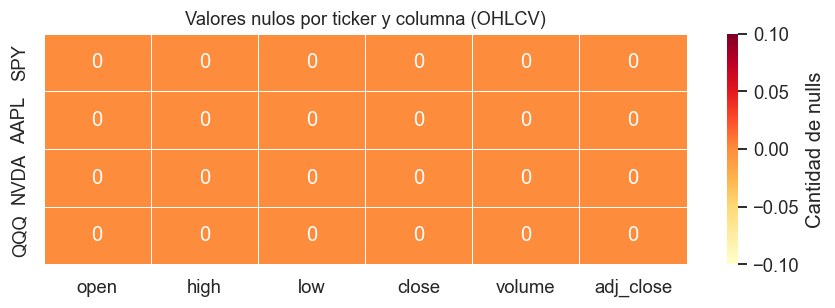


Total de valores nulos en todo el dataset: 0
✓ Dataset limpio — sin valores nulos.


In [8]:
# --- Null value heatmap ---
# We build a matrix where each row is a ticker and each column is an
# OHLCV column. Each cell holds the number of nulls.

null_matrix = pd.DataFrame(
    {ticker: df.isnull().sum() for ticker, df in data.items()}
).T  # (tickers x columns)

fig, ax = plt.subplots(figsize=(8, 3))
sns.heatmap(
    null_matrix,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Number of nulls"},
)
ax.set_title("Null values by ticker and column (OHLCV)", fontsize=12)
ax.set_ylabel("")
plt.tight_layout()
plt.show()

total_nulls = null_matrix.values.sum()
print(f"\nTotal null values across the dataset: {total_nulls}")
if total_nulls == 0:
    print("✓ Clean dataset — no null values.")


### 1.3 Bar distribution by hour of day

We expect a relatively uniform distribution during market hours (9:30-16:00 ET = 13:30-20:00 UTC), with possible spikes at the open and the close.


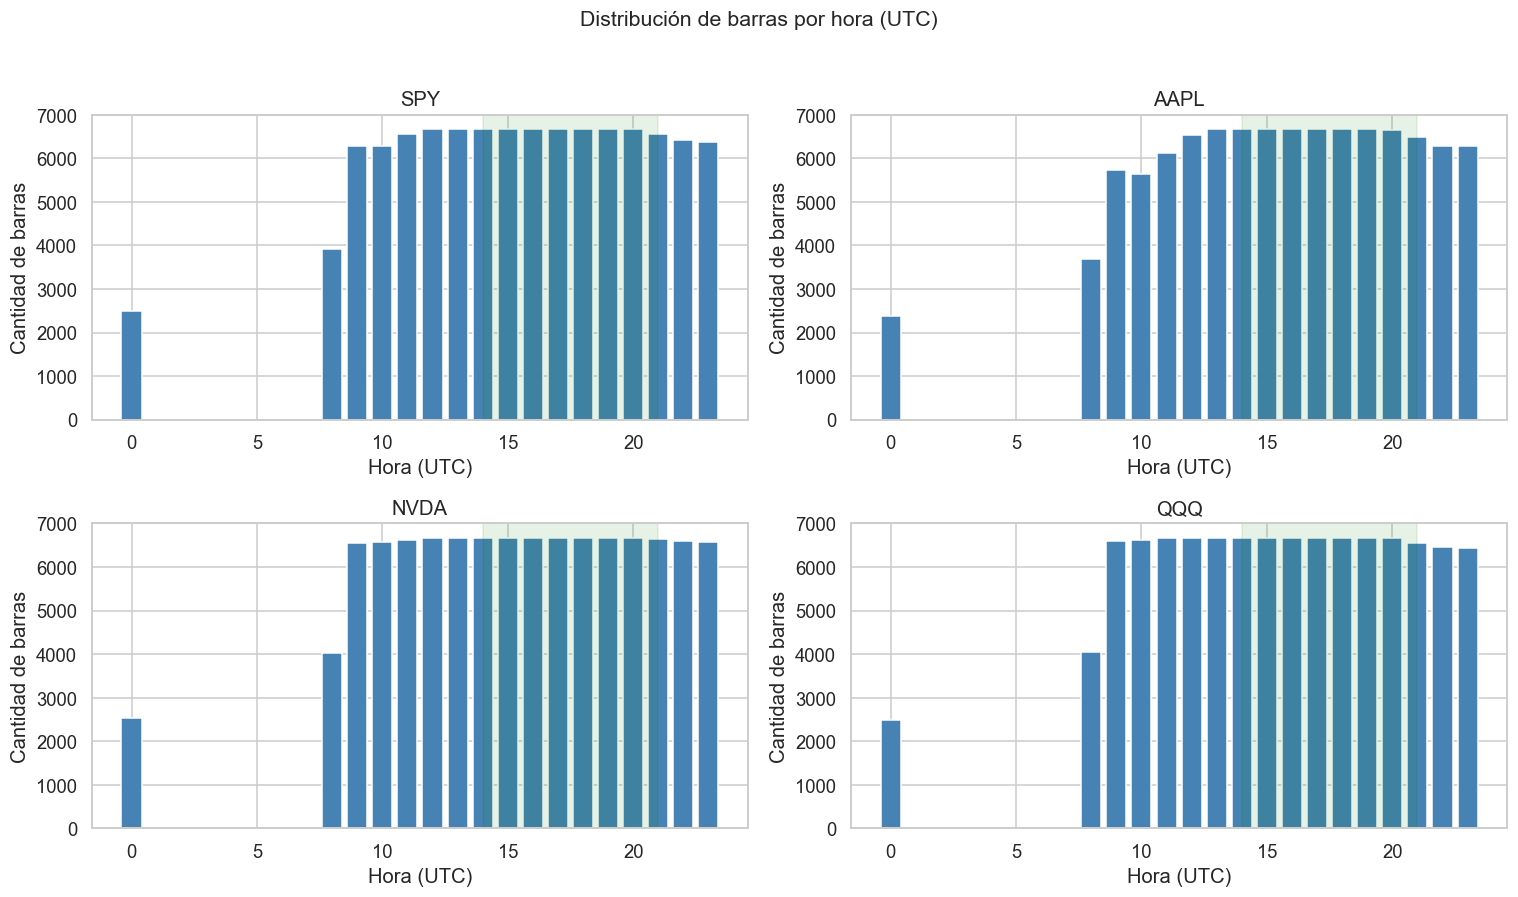

In [9]:
# --- Bar distribution by hour (UTC) ---
# Alpaca returns timestamps in UTC. The US market trades 14:30-21:00 UTC (9:30-16:00 ET).
# Bars outside that range -> pre/post market data.

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, ticker in zip(axes.flat, E3_TICKERS):
    if ticker not in data:
        continue
    hours = data[ticker].index.hour
    hour_counts = hours.value_counts().sort_index()
    ax.bar(hour_counts.index, hour_counts.values, color="steelblue", edgecolor="white")
    ax.set_title(f"{ticker}")
    ax.set_xlabel("Hour (UTC)")
    ax.set_ylabel("Number of bars")
    # Mark regular market hours (14:30-21:00 UTC)
    ax.axvspan(14, 21, alpha=0.1, color="green", label="Regular market")

fig.suptitle("Bar distribution by hour (UTC)", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


### 1.4 Normalized prices (base 100)


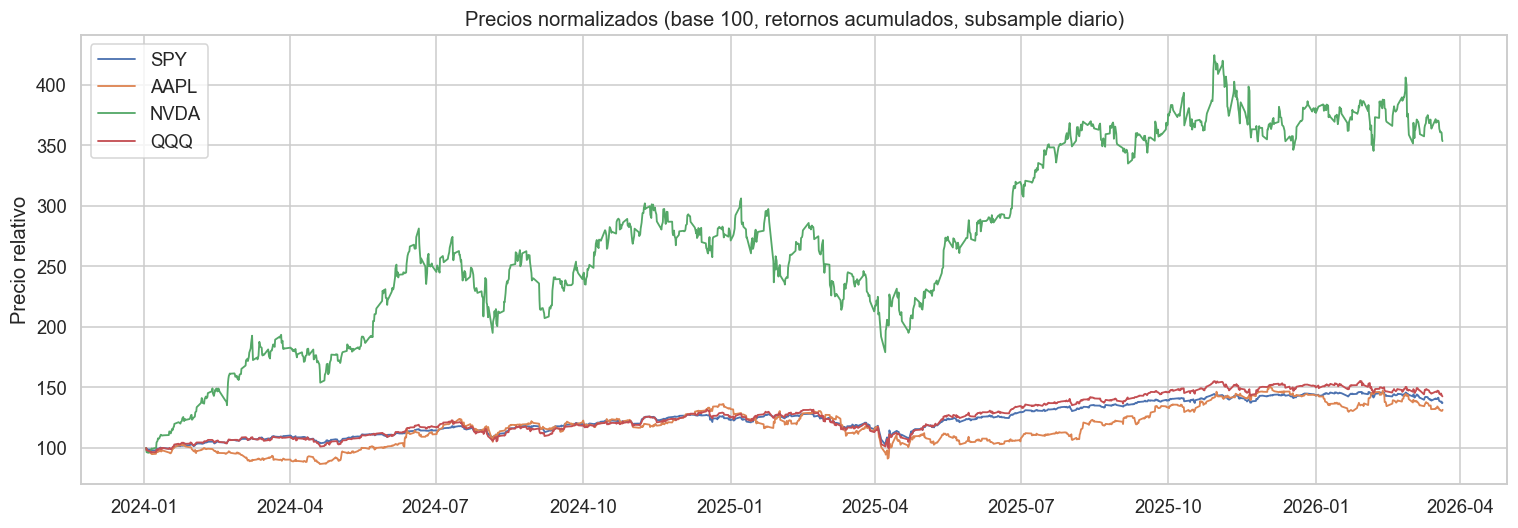

In [10]:
# --- Base-100 normalized prices ---
# We use cumulative returns instead of close/close[0] to stay robust to any future
# adjustment. Both are equivalent when prices are properly adjusted.

fig, ax = plt.subplots(figsize=(14, 5))
for ticker, df_t in data.items():
    log_ret = np.log(df_t["close"] / df_t["close"].shift(1)).fillna(0)
    cum_ret = np.exp(log_ret.cumsum()) * 100  # Base 100
    # Subsample every 78 bars (~1 day) so the chart does not get too heavy
    ax.plot(cum_ret.iloc[::78].index, cum_ret.iloc[::78].values, label=ticker, linewidth=1.2)

ax.set_title("Normalized prices (base 100, cumulative returns, daily subsample)")
ax.set_ylabel("Relative price")
ax.legend()
fig.tight_layout()
plt.show()


### 1.5 Distribution of 5-min returns

Unlike daily returns, 5-min returns have distributions with even fatter tails (higher kurtosis) and are centered very close to zero.


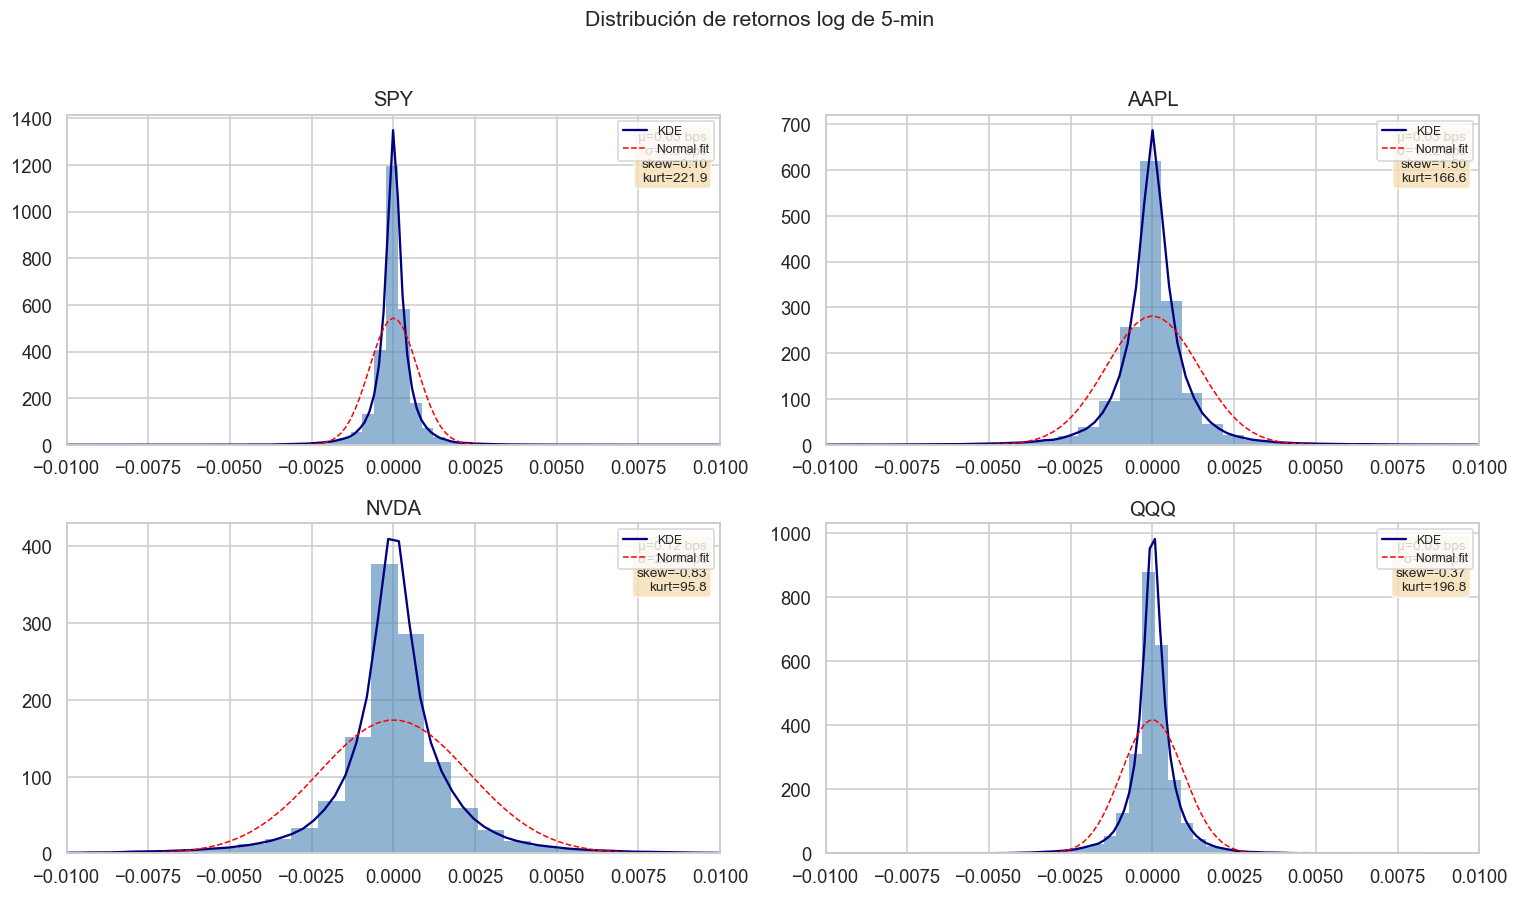

In [11]:
# --- Histograms of 5-min returns with a normal fit and statistics ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, ticker in zip(axes.flat, E3_TICKERS):
    if ticker not in data:
        continue
    close = data[ticker]["close"]
    log_ret = np.log(close / close.shift(1)).dropna().values

    # Histogram + KDE
    ax.hist(log_ret, bins=200, density=True, alpha=0.6, color="steelblue", edgecolor="none")
    kde_x = np.linspace(log_ret.min(), log_ret.max(), 500)
    kde = stats.gaussian_kde(log_ret)
    ax.plot(kde_x, kde(kde_x), color="navy", linewidth=1.5, label="KDE")

    # Normal fit for comparison
    mu, sigma = log_ret.mean(), log_ret.std()
    normal_y = stats.norm.pdf(kde_x, mu, sigma)
    ax.plot(kde_x, normal_y, "--", color="red", linewidth=1, label="Normal fit")

    # Statistics printed on the chart
    kurt = stats.kurtosis(log_ret, fisher=True)
    skew = stats.skew(log_ret)
    ax.text(0.98, 0.95,
            f"μ={mu*1e4:.2f} bps\nσ={sigma*1e4:.1f} bps\nskew={skew:.2f}\nkurt={kurt:.1f}",
            transform=ax.transAxes, va="top", ha="right", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))
    ax.set_title(f"{ticker}")
    ax.set_xlim(-0.01, 0.01)  # Zoom to ±1% to see the shape
    ax.legend(fontsize=8)

fig.suptitle("Distribution of 5-min log returns", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


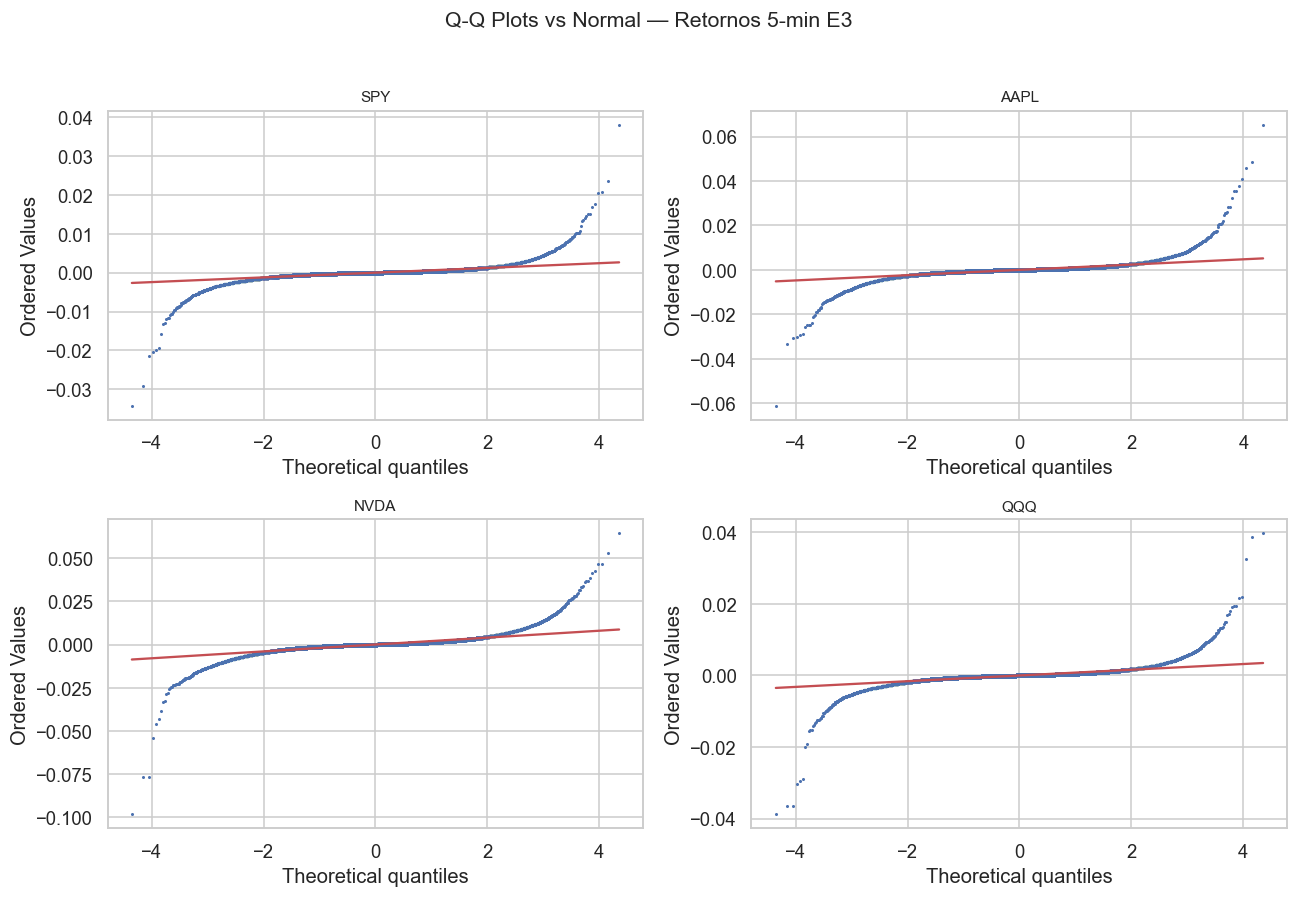

In [12]:
# --- Q-Q plots (quantile-quantile) against the normal distribution ---
# Compares observed quantiles against the theoretical ones of a normal.
# Departures in the tails = fat-tailed distribution (typical in finance).

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, ticker in enumerate(E3_TICKERS):
    ax = axes[i]
    log_ret = np.log(data[ticker]["close"]).diff().dropna()
    stats.probplot(log_ret, dist="norm", plot=ax)
    ax.set_title(f"{ticker}", fontsize=10)
    ax.get_lines()[0].set_markersize(1)  # Small points (5-min data is dense)

fig.suptitle("Q-Q plots vs normal — E3 5-min returns", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### 1.6 Volume distribution (log scale)

Trading volume varies enormously across tickers (SPY moves orders of magnitude more than AAPL on 5-min bars). A logarithmic scale makes the distributions comparable.


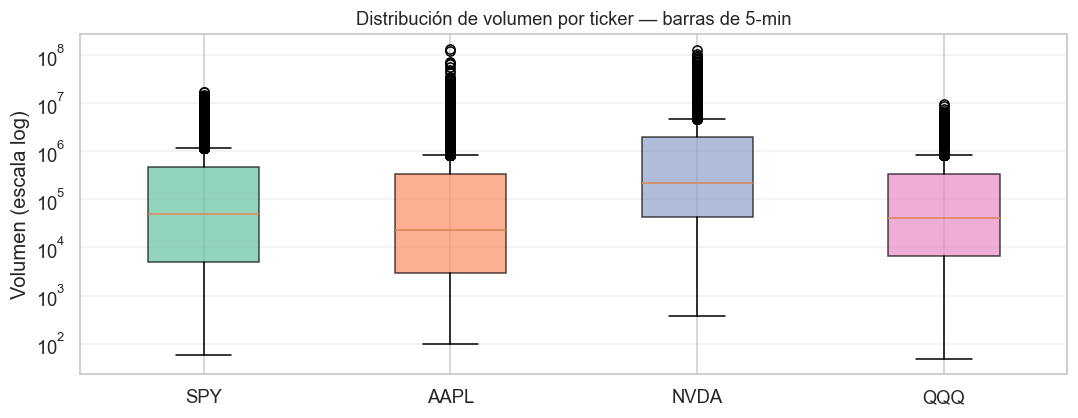

  SPY: mediana=49,410  media=354,735  min=59  max=16,660,329  zeros=0
  AAPL: mediana=23,151  media=296,368  min=100  max=130,782,778  zeros=0
  NVDA: mediana=219,390  media=1,507,210  min=370  max=128,116,952  zeros=0
  QQQ: mediana=41,338  media=235,994  min=48  max=9,443,699  zeros=0


In [13]:
# --- Volume boxplot on a logarithmic scale ---
vol_data = []
vol_labels = []
for ticker in E3_TICKERS:
    v = data[ticker]["volume"].replace(0, np.nan).dropna()
    vol_data.append(v.values)
    vol_labels.append(ticker)

fig, ax = plt.subplots(figsize=(10, 4))
bp = ax.boxplot(vol_data, labels=vol_labels, patch_artist=True, vert=True)
colors = sns.color_palette("Set2", len(E3_TICKERS))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_yscale("log")
ax.set_ylabel("Volume (log scale)")
ax.set_title("Volume distribution per ticker — 5-min bars", fontsize=12)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# Volume statistics
for ticker in E3_TICKERS:
    v = data[ticker]["volume"]
    print(f"  {ticker}: median={v.median():,.0f}  mean={v.mean():,.0f}  "
          f"min={v.min():,.0f}  max={v.max():,.0f}  zeros={int((v==0).sum())}")


---

## 2. Intraday seasonality

An analysis exclusive to high-frequency data. In equity markets, microstructure produces reproducible patterns:
- **Volume**: "U" shape (high at the open and close, low at midday)
- **Volatility**: similar pattern to volume
- **Mean returns**: possible open (overnight gap) and close effects

These patterns are why `build_features.py` includes `tod_sin`/`tod_cos` as cyclical features.

### 2.1 Average volume by hour


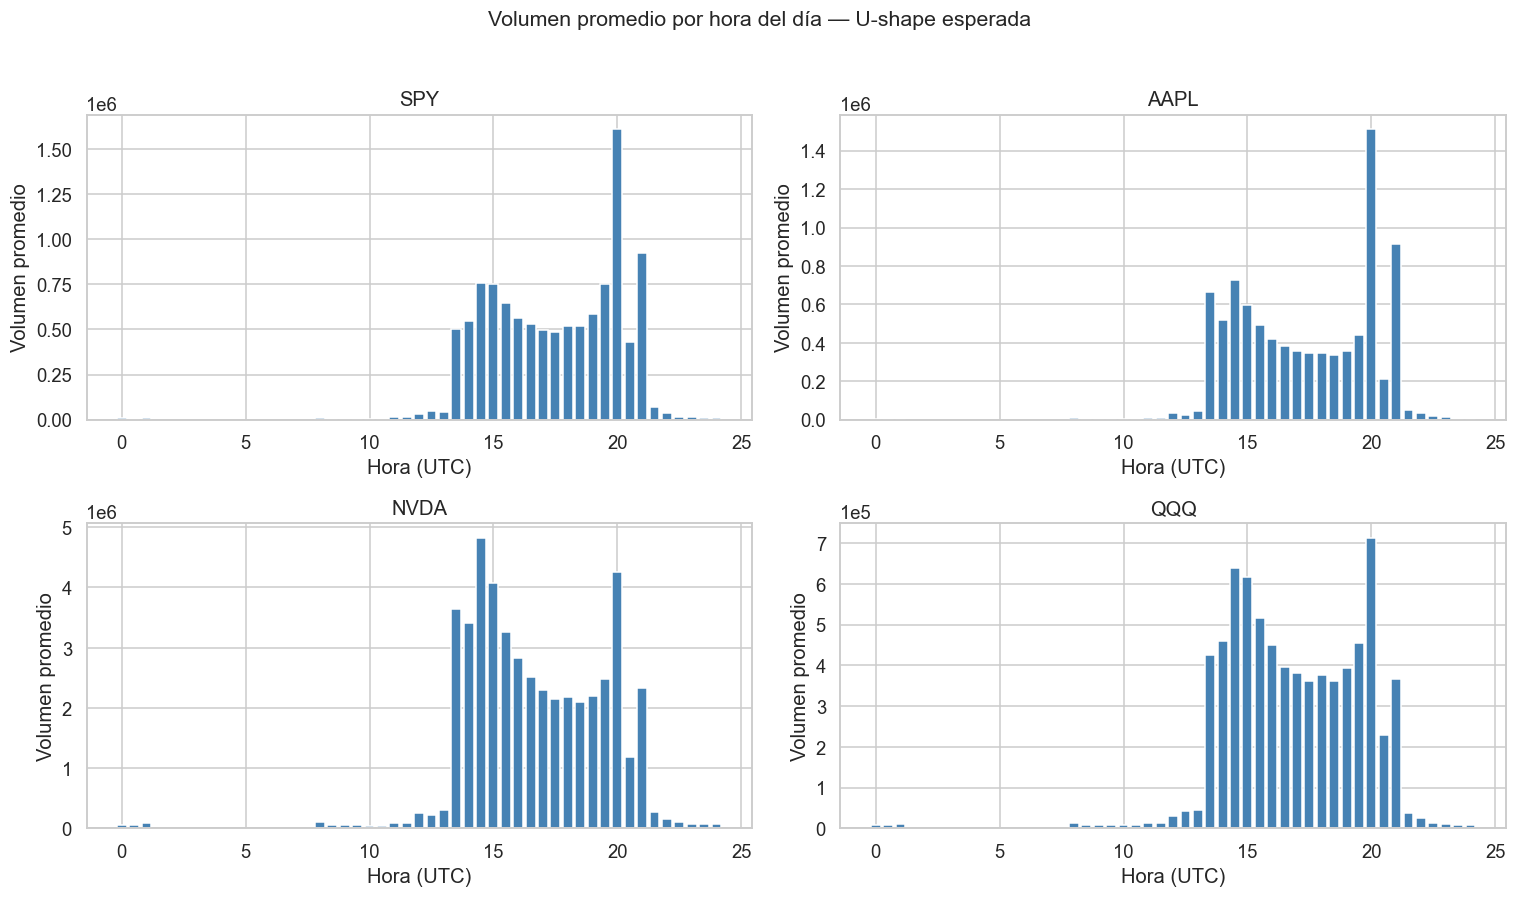

In [14]:
# --- Average volume by hour of day (UTC) ---
# We expect the classic "U-shape": high at the open (14:30 UTC) and close (20:55 UTC),
# low at midday (~17:00 UTC).

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, ticker in zip(axes.flat, E3_TICKERS):
    if ticker not in data:
        continue
    df_t = data[ticker].copy()
    df_t["hour"] = df_t.index.hour + df_t.index.minute / 60  # Decimal hour (14.5 = 14:30)

    # Group by hour (30-min bins) to smooth it out
    df_t["hour_bin"] = (df_t["hour"] * 2).round() / 2  # Round to 0.5h
    vol_by_hour = df_t.groupby("hour_bin")["volume"].mean()

    ax.bar(vol_by_hour.index, vol_by_hour.values, width=0.4, color="steelblue", edgecolor="white")
    ax.set_title(f"{ticker}")
    ax.set_xlabel("Hour (UTC)")
    ax.set_ylabel("Average volume")
    ax.ticklabel_format(axis="y", style="scientific", scilimits=(0, 0))

fig.suptitle("Average volume by hour of day — expected U-shape", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


### 2.2 Volatility by hour of day


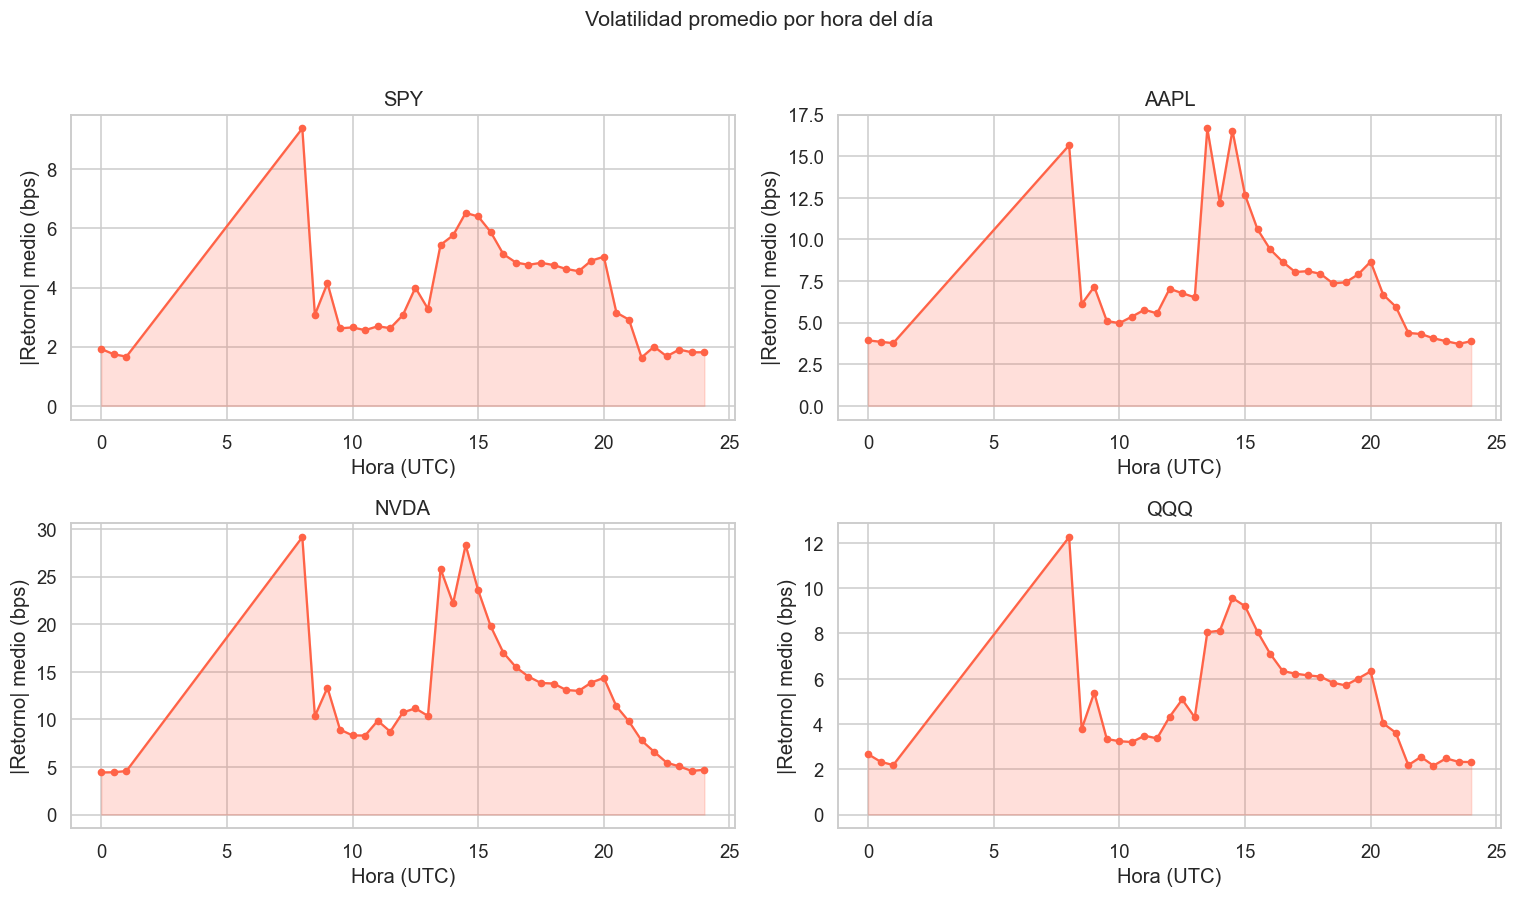

In [15]:
# --- Average volatility (|return|) by hour of day ---
# Expected pattern: similar to volume (U-shape).
# This matters for the model: a +0.05% signal at 14:30 UTC (the open)
# does not mean the same as the same signal at 17:00 UTC (quiet midday).

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, ticker in zip(axes.flat, E3_TICKERS):
    if ticker not in data:
        continue
    df_t = data[ticker].copy()
    df_t["abs_ret"] = np.abs(np.log(df_t["close"] / df_t["close"].shift(1)))
    df_t["hour_bin"] = ((df_t.index.hour + df_t.index.minute / 60) * 2).round() / 2

    vol_by_hour = df_t.groupby("hour_bin")["abs_ret"].mean() * 1e4  # in bps

    ax.plot(vol_by_hour.index, vol_by_hour.values, "o-", color="tomato", markersize=4)
    ax.fill_between(vol_by_hour.index, vol_by_hour.values, alpha=0.2, color="tomato")
    ax.set_title(f"{ticker}")
    ax.set_xlabel("Hour (UTC)")
    ax.set_ylabel("Mean |return| (bps)")

fig.suptitle("Average volatility by hour of day", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


### 2.3 Mean return by hour of day

If the mean return varies significantly by hour, there is an exploitable intraday inefficiency (or a data artifact).


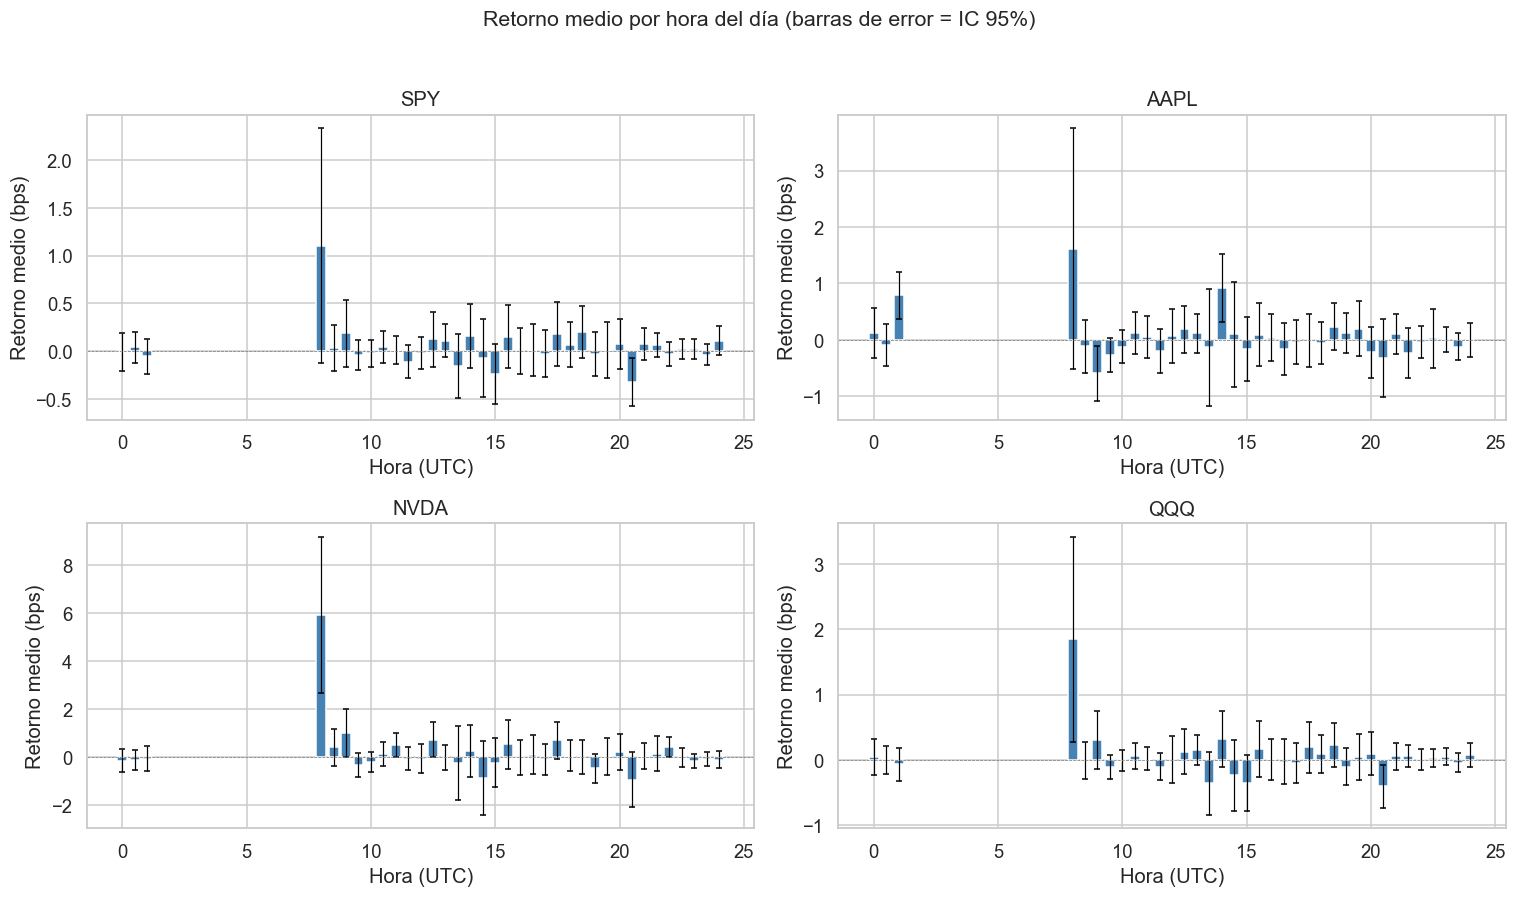

In [16]:
# --- Mean return by hour of day (with 95% CI) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, ticker in zip(axes.flat, E3_TICKERS):
    if ticker not in data:
        continue
    df_t = data[ticker].copy()
    df_t["log_ret"] = np.log(df_t["close"] / df_t["close"].shift(1))
    df_t["hour_bin"] = ((df_t.index.hour + df_t.index.minute / 60) * 2).round() / 2

    grouped = df_t.groupby("hour_bin")["log_ret"]
    means = grouped.mean() * 1e4  # bps
    sems = grouped.sem() * 1e4    # standard error of the mean, in bps

    ax.bar(means.index, means.values, width=0.4, color="steelblue", edgecolor="white")
    ax.errorbar(means.index, means.values, yerr=1.96 * sems.values,
                fmt="none", color="black", capsize=2, linewidth=0.8)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.set_title(f"{ticker}")
    ax.set_xlabel("Hour (UTC)")
    ax.set_ylabel("Mean return (bps)")

fig.suptitle("Mean return by hour of day (error bars = 95% CI)", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


---

## 3. Technical features

`compute_intraday_features()` derives 17 indicators from 5-min OHLCV:

| Feature | Description | Window | Intraday adaptation |
|---------|-------------|---------|---------------------|
| `ret_1` | 1-bar log return | 1 bar | — |
| `ret_12m` | 1h momentum (rolling return sum) | 12 bars | — |
| `vol_24` | 2h volatility | 24 bars | — |
| `vol_96` | 1-day volatility | 96 bars | — |
| `range_pct` | Range (high-low)/close | 1 bar | — |
| `atr_14` | Normalized ATR proxy | 14 bars | — |
| `vol_z_96` | Volume z-score vs the 1-day mean | 96 bars | — |
| `tod_sin` | Time of day (cyclical, sine) | — | — |
| `tod_cos` | Time of day (cyclical, cosine) | — | — |
| `dow_sin` | Day of week (cyclical, sine) | — | — |
| `dow_cos` | Day of week (cyclical, cosine) | — | — |
| `vwap_dev` | Deviation from the intraday VWAP | since the open | VWAP reset per day |
| `vol_ratio` | Short/long volatility ratio | 24/96 bars | — |
| `rsi_14` | Classic RSI (Wilder EWM) | 14 bars | — |
| `macd_hist` | MACD histogram normalized by price | EMA 12/26/9 bars | EMA(12)=60min, EMA(26)=130min, normalized by close |
| `bb_pct_b` | Bollinger Bands %B | SMA 20 bars = 100 min | Position within the ±2σ bands |
| `close_sma78_dist` | Deviation from a one-session SMA | 78 bars = 1 trading day | Analogous to close_sma50_dist in E2 |

**Warm-up**: ~96 bars per ticker are lost (the longest rolling lookback = `vol_96` and `sma78`).

### 3.1 Compute features and target


In [17]:
# --- Compute features and target for every ticker ---
features_all = {}   # {ticker: feature DataFrame}
targets_all = {}    # {ticker: target Series}
combined_all = {}   # {ticker: features + target, NaN-free}

for ticker, df_t in data.items():
    feats = compute_intraday_features(df_t)
    target = make_target_return(df_t, horizon_bars=HORIZON_BARS)

    # Merge and drop NaN (feature warm-up + the target's forward horizon)
    combined = pd.concat([feats, target], axis=1).dropna()

    features_all[ticker] = combined[feats.columns]
    targets_all[ticker] = combined[target.name]
    combined_all[ticker] = combined

    n_lost = len(df_t) - len(combined)
    print(
        f"  {ticker}: {len(combined):,} valid samples "
        f"({n_lost:,} lost to warm-up + horizon, "
        f"{len(feats.columns)} features)"
    )


  SPY: 104,834 muestras válidas (102 perdidas por warm-up + horizonte, 17 features)
  AAPL: 102,393 muestras válidas (102 perdidas por warm-up + horizonte, 17 features)
  NVDA: 106,081 muestras válidas (102 perdidas por warm-up + horizonte, 17 features)
  QQQ: 105,782 muestras válidas (102 perdidas por warm-up + horizonte, 17 features)


### 3.2 Feature + target correlation matrix


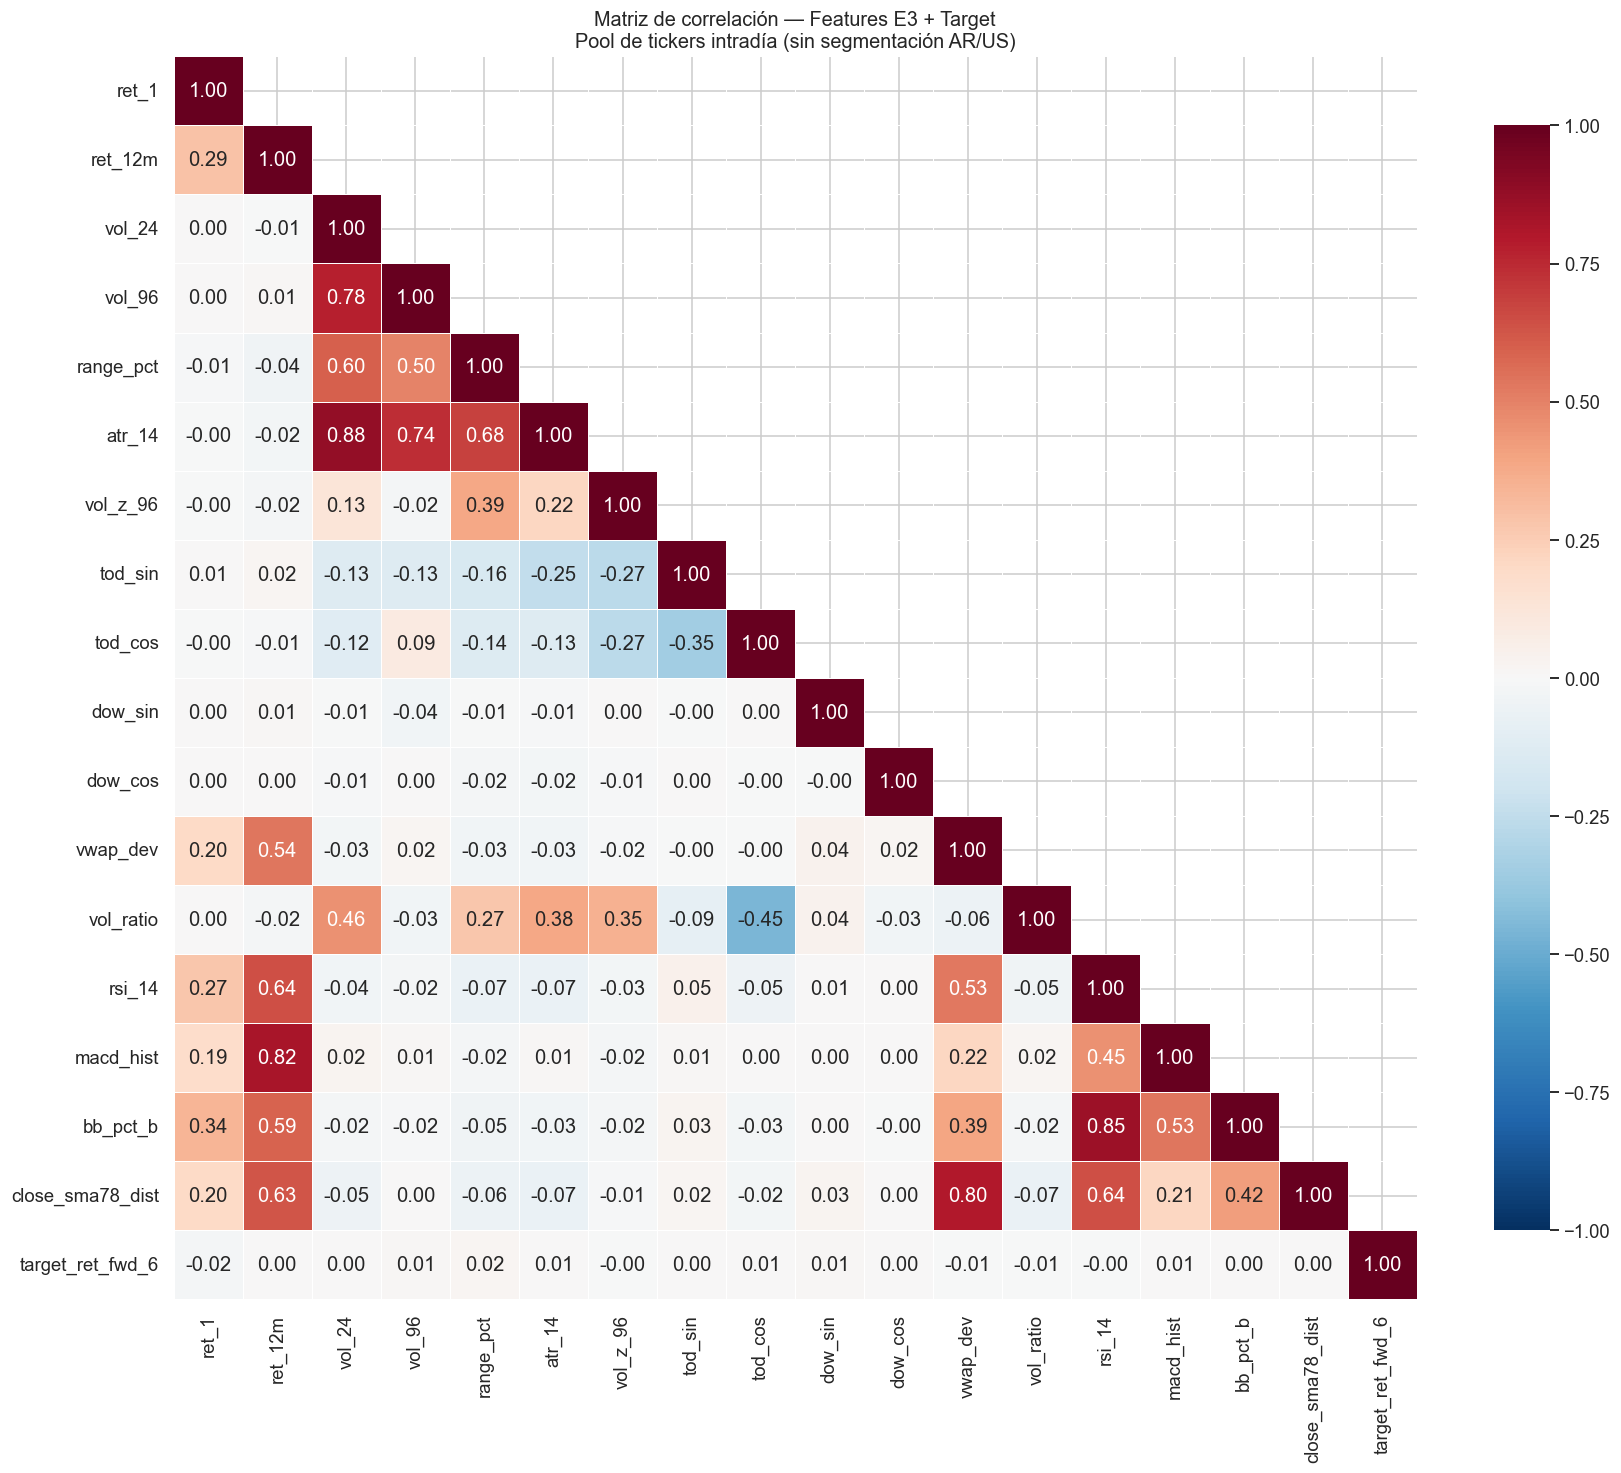


⚠️ [Pool E3] Pares con correlación |r| > 0.7:
  vol_24 ↔ atr_14: r = 0.881
  rsi_14 ↔ bb_pct_b: r = 0.853
  ret_12m ↔ macd_hist: r = 0.822
  vwap_dev ↔ close_sma78_dist: r = 0.803
  vol_24 ↔ vol_96: r = 0.778
  vol_96 ↔ atr_14: r = 0.74


In [31]:
# --- Correlation matrix between features + target (E3 pool, no AR/US split) ---
# E3 has no market grouping (AR vs US): every ticker belongs to the same universe.
# The ticker pool is combined into a single global correlation matrix.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

if "E3_TICKERS" not in globals() or "features_all" not in globals() or "targets_all" not in globals():
    raise RuntimeError("Base variables missing. Run the setup and feature/target cells first.")

if "HORIZON_BARS" in globals():
    target_col = f"target_ret_fwd_{HORIZON_BARS}"
else:
    sample_ticker = next((t for t in E3_TICKERS if t in targets_all), None)
    if sample_ticker is None:
        raise RuntimeError("No targets available for the E3 tickers.")
    target_col = targets_all[sample_ticker].name

pool_feat_target = pd.concat(
    [
        pd.concat([features_all[t], targets_all[t]], axis=1)
        for t in E3_TICKERS
        if t in features_all and t in targets_all
    ],
    ignore_index=True,
)

if pool_feat_target.empty:
    raise RuntimeError("The features+target pool is empty. Check the previous cells.")

corr = pool_feat_target.corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Correlation matrix — E3 features + target\nIntraday ticker pool (no AR/US split)", fontsize=13)
plt.tight_layout()
plt.show()

# Highly correlated pairs
HIGH_CORR_THRESHOLD = 0.7
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > HIGH_CORR_THRESHOLD:
            high_corr.append((corr.columns[i], corr.columns[j], round(r, 3)))

if high_corr:
    print(f"\n⚠️ [E3 pool] Pairs with correlation |r| > {HIGH_CORR_THRESHOLD}:")
    for f1, f2, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {f1} ↔ {f2}: r = {r}")
else:
    print(f"\n✓ [E3 pool] No pairs with correlation |r| > {HIGH_CORR_THRESHOLD}")


In [19]:
# --- Automatic multicollinearity detection (|r| > 0.7) ---
# Feature pairs with high correlation may be redundant.
# We review every pair for each ticker and report those above the threshold.

MULTICOL_THRESHOLD = 0.7
target_col = f"target_ret_fwd_{HORIZON_BARS}"

print(f"Multicollinearity threshold: |r| > {MULTICOL_THRESHOLD}\n")
print("=" * 60)

for ticker in E3_TICKERS:
    if ticker not in combined_all:
        continue
    feat_cols = [c for c in combined_all[ticker].columns if c != target_col]
    corr = combined_all[ticker][feat_cols].corr()

    # Extract unique pairs with |r| > threshold
    pairs = []
    for i in range(len(feat_cols)):
        for j in range(i + 1, len(feat_cols)):
            r = corr.iloc[i, j]
            if abs(r) > MULTICOL_THRESHOLD:
                pairs.append((feat_cols[i], feat_cols[j], r))

    print(f"\n{ticker}: {len(pairs)} pair(s) with |r| > {MULTICOL_THRESHOLD}")
    for f1, f2, r in sorted(pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {f1:<15} ↔ {f2:<15}  r = {r:+.3f}  {'⚠️' if abs(r) > 0.85 else ''}")

print("\n" + "=" * 60)
print("\nNote: pairs with |r| > 0.85 (⚠️) are strong candidates for dropping one of the two.")


Umbral de multicolinealidad: |r| > 0.7


SPY: 5 par(es) con |r| > 0.7
  rsi_14          ↔ bb_pct_b         r = +0.851  ⚠️
  vol_24          ↔ atr_14           r = +0.844  
  ret_12m         ↔ macd_hist        r = +0.818  
  vwap_dev        ↔ close_sma78_dist  r = +0.814  
  vol_24          ↔ vol_96           r = +0.759  

AAPL: 5 par(es) con |r| > 0.7
  rsi_14          ↔ bb_pct_b         r = +0.859  ⚠️
  vol_24          ↔ atr_14           r = +0.845  
  ret_12m         ↔ macd_hist        r = +0.822  
  vwap_dev        ↔ close_sma78_dist  r = +0.800  
  vol_24          ↔ vol_96           r = +0.702  

NVDA: 7 par(es) con |r| > 0.7
  vol_24          ↔ atr_14           r = +0.859  ⚠️
  rsi_14          ↔ bb_pct_b         r = +0.857  ⚠️
  ret_12m         ↔ macd_hist        r = +0.823  
  vwap_dev        ↔ close_sma78_dist  r = +0.804  
  ret_12m         ↔ rsi_14           r = +0.716  
  rsi_14          ↔ close_sma78_dist  r = +0.715  
  vol_24          ↔ vol_96           r = +0.706  

QQQ: 

### 3.3 Feature-target correlation: cross-ticker comparison

A consolidated view: for each feature, how much does it correlate with the target on each ticker? Reading it together with the inter-feature correlation matrix (section 3.2) is what grounds the selection decisions documented in the conclusions at the end of this section.


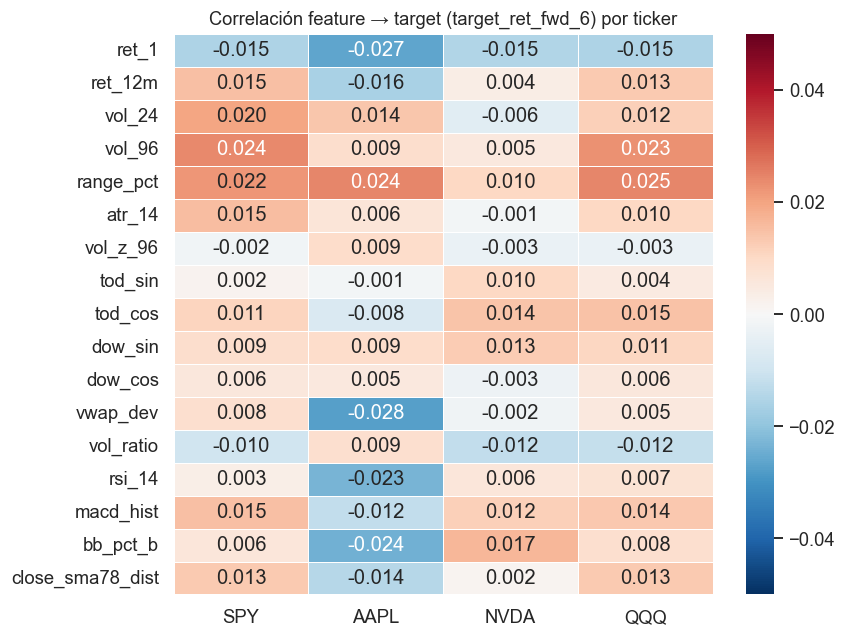


Ranking de features por |correlación| promedio con target:
  range_pct       0.0203
  ret_1           0.0181
  vol_96          0.0152
  bb_pct_b        0.0138
  macd_hist       0.0133
  vol_24          0.0128
  ret_12m         0.0119
  tod_cos         0.0119
  vwap_dev        0.0108
  vol_ratio       0.0107
  close_sma78_dist 0.0105
  dow_sin         0.0103
  rsi_14          0.0099
  atr_14          0.0084
  dow_cos         0.0048
  tod_sin         0.0045
  vol_z_96        0.0044


In [20]:
# --- Cross-ticker feature-target correlation heatmap ---
# Each cell = correlation of one feature with the target for one ticker.
# This reveals which features carry consistent signal vs ticker-specific signal.

target_col = f"target_ret_fwd_{HORIZON_BARS}"
feat_cols = list(features_all[E3_TICKERS[0]].columns)

corr_matrix = pd.DataFrame(index=feat_cols, columns=E3_TICKERS, dtype=float)
for ticker in E3_TICKERS:
    if ticker not in combined_all:
        continue
    for feat in feat_cols:
        corr_matrix.loc[feat, ticker] = combined_all[ticker][feat].corr(combined_all[ticker][target_col])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix.astype(float), annot=True, fmt=".3f", cmap="RdBu_r",
    center=0, vmin=-0.05, vmax=0.05, ax=ax,
    linewidths=0.5,
)
ax.set_title(f"Feature → target correlation ({target_col}) per ticker", fontsize=12)
fig.tight_layout()
plt.show()

# Ranking: features with the highest average |correlation|
avg_abs_corr = corr_matrix.astype(float).abs().mean(axis=1).sort_values(ascending=False)
print("\nFeature ranking by average |correlation| with the target:")
for feat, val in avg_abs_corr.items():
    print(f"  {feat:<15} {val:.4f}")


### Conclusions — Correlation analysis and feature selection

The inter-feature correlation matrix analysis (section 3.2) found **6 pairs with |r| > 0.7**, showing structural redundancy in the initial 17-feature set. The removal decisions taken are documented below:

| Pair | r | Dropped feature | Kept feature | Rationale |
|-----|---|-------------------|--------------------|---------------|
|  ↔  | 0.881 |  |  | atr_14 on 5-min data (14 bars ~ 70 min) measures the same volatility dimension as vol_24 (24 bars ~ 2h). Double correlation (also r=0.74 with vol_96). range_pct already covers the bar range. |
|  ↔  | 0.853 |  |  | Both flag overbought/oversold. RSI is more robust: it does not depend on the bands' sigma parameter and has lower collinearity with the rest of the set. |
|  ↔  | 0.822 |  |  | MACD(12,26,9) on 5-min data produces 60/130/45 min windows that overlap the 1h momentum. Its standard parameters were designed for daily data and lose interpretability at intraday scale. |
|  ↔  | 0.803 |  |  | Both measure the price deviation from the full session. vwap_dev is the canonical intraday reference: it weights by volume and resets naturally each session. |
|  ↔  | 0.778 |  (as output) |  | vol_96 as a standalone feature is redundant with vol_24. It is kept **only as an intermediate variable** to compute , which captures the contrast between short and long-term regimes. |

#### Resulting set: 12 features

| Feature | Description | Kept because... |
|---------|-------------|----------------------|
|  | 1-bar log return | Pipeline baseline; no high correlation |
|  | 1h momentum | Highest IC signal, interpretable, covers macd_hist |
|  | 2h volatility | More reactive short-term volatility |
|  | vol_24 / vol_96 | Captures regime change without redundancy |
|  | Range (H-L)/close | Point-in-time range, no high correlation |
|  | Volume z-score vs 1 day | Volume dimension, orthogonal to the rest |
|  | Deviation from the daily VWAP | Canonical intraday reference |
|  | Wilder RSI, 14 bars | Relative momentum, covers bb_pct_b |
|  /  | Time of day (cyclical) | Intraday seasonality |
|  /  | Day of week (cyclical) | Monday/Friday effect |

> **Methodological note**: the dropped features **were not deleted from the code** (); they were commented out with the explicit rationale. That makes them easy to restore if a future experiment shows they add signal on top of the reduced set.

> **Heuristic 5 applied**: reduce multicollinearity before training (see , section 1.1). The 12-feature set improves parsimony without sacrificing the key informative dimensions: momentum, volatility regime, intraday reference, relative momentum and seasonality.


### 3.4 Feature vs target (scatter + regression)

Scatter plots of each feature against the target, with a regression line, the Pearson coefficient r and the p-value. For intraday datasets with ~100K points we subsample for the visualization but compute the statistics on the full dataset.


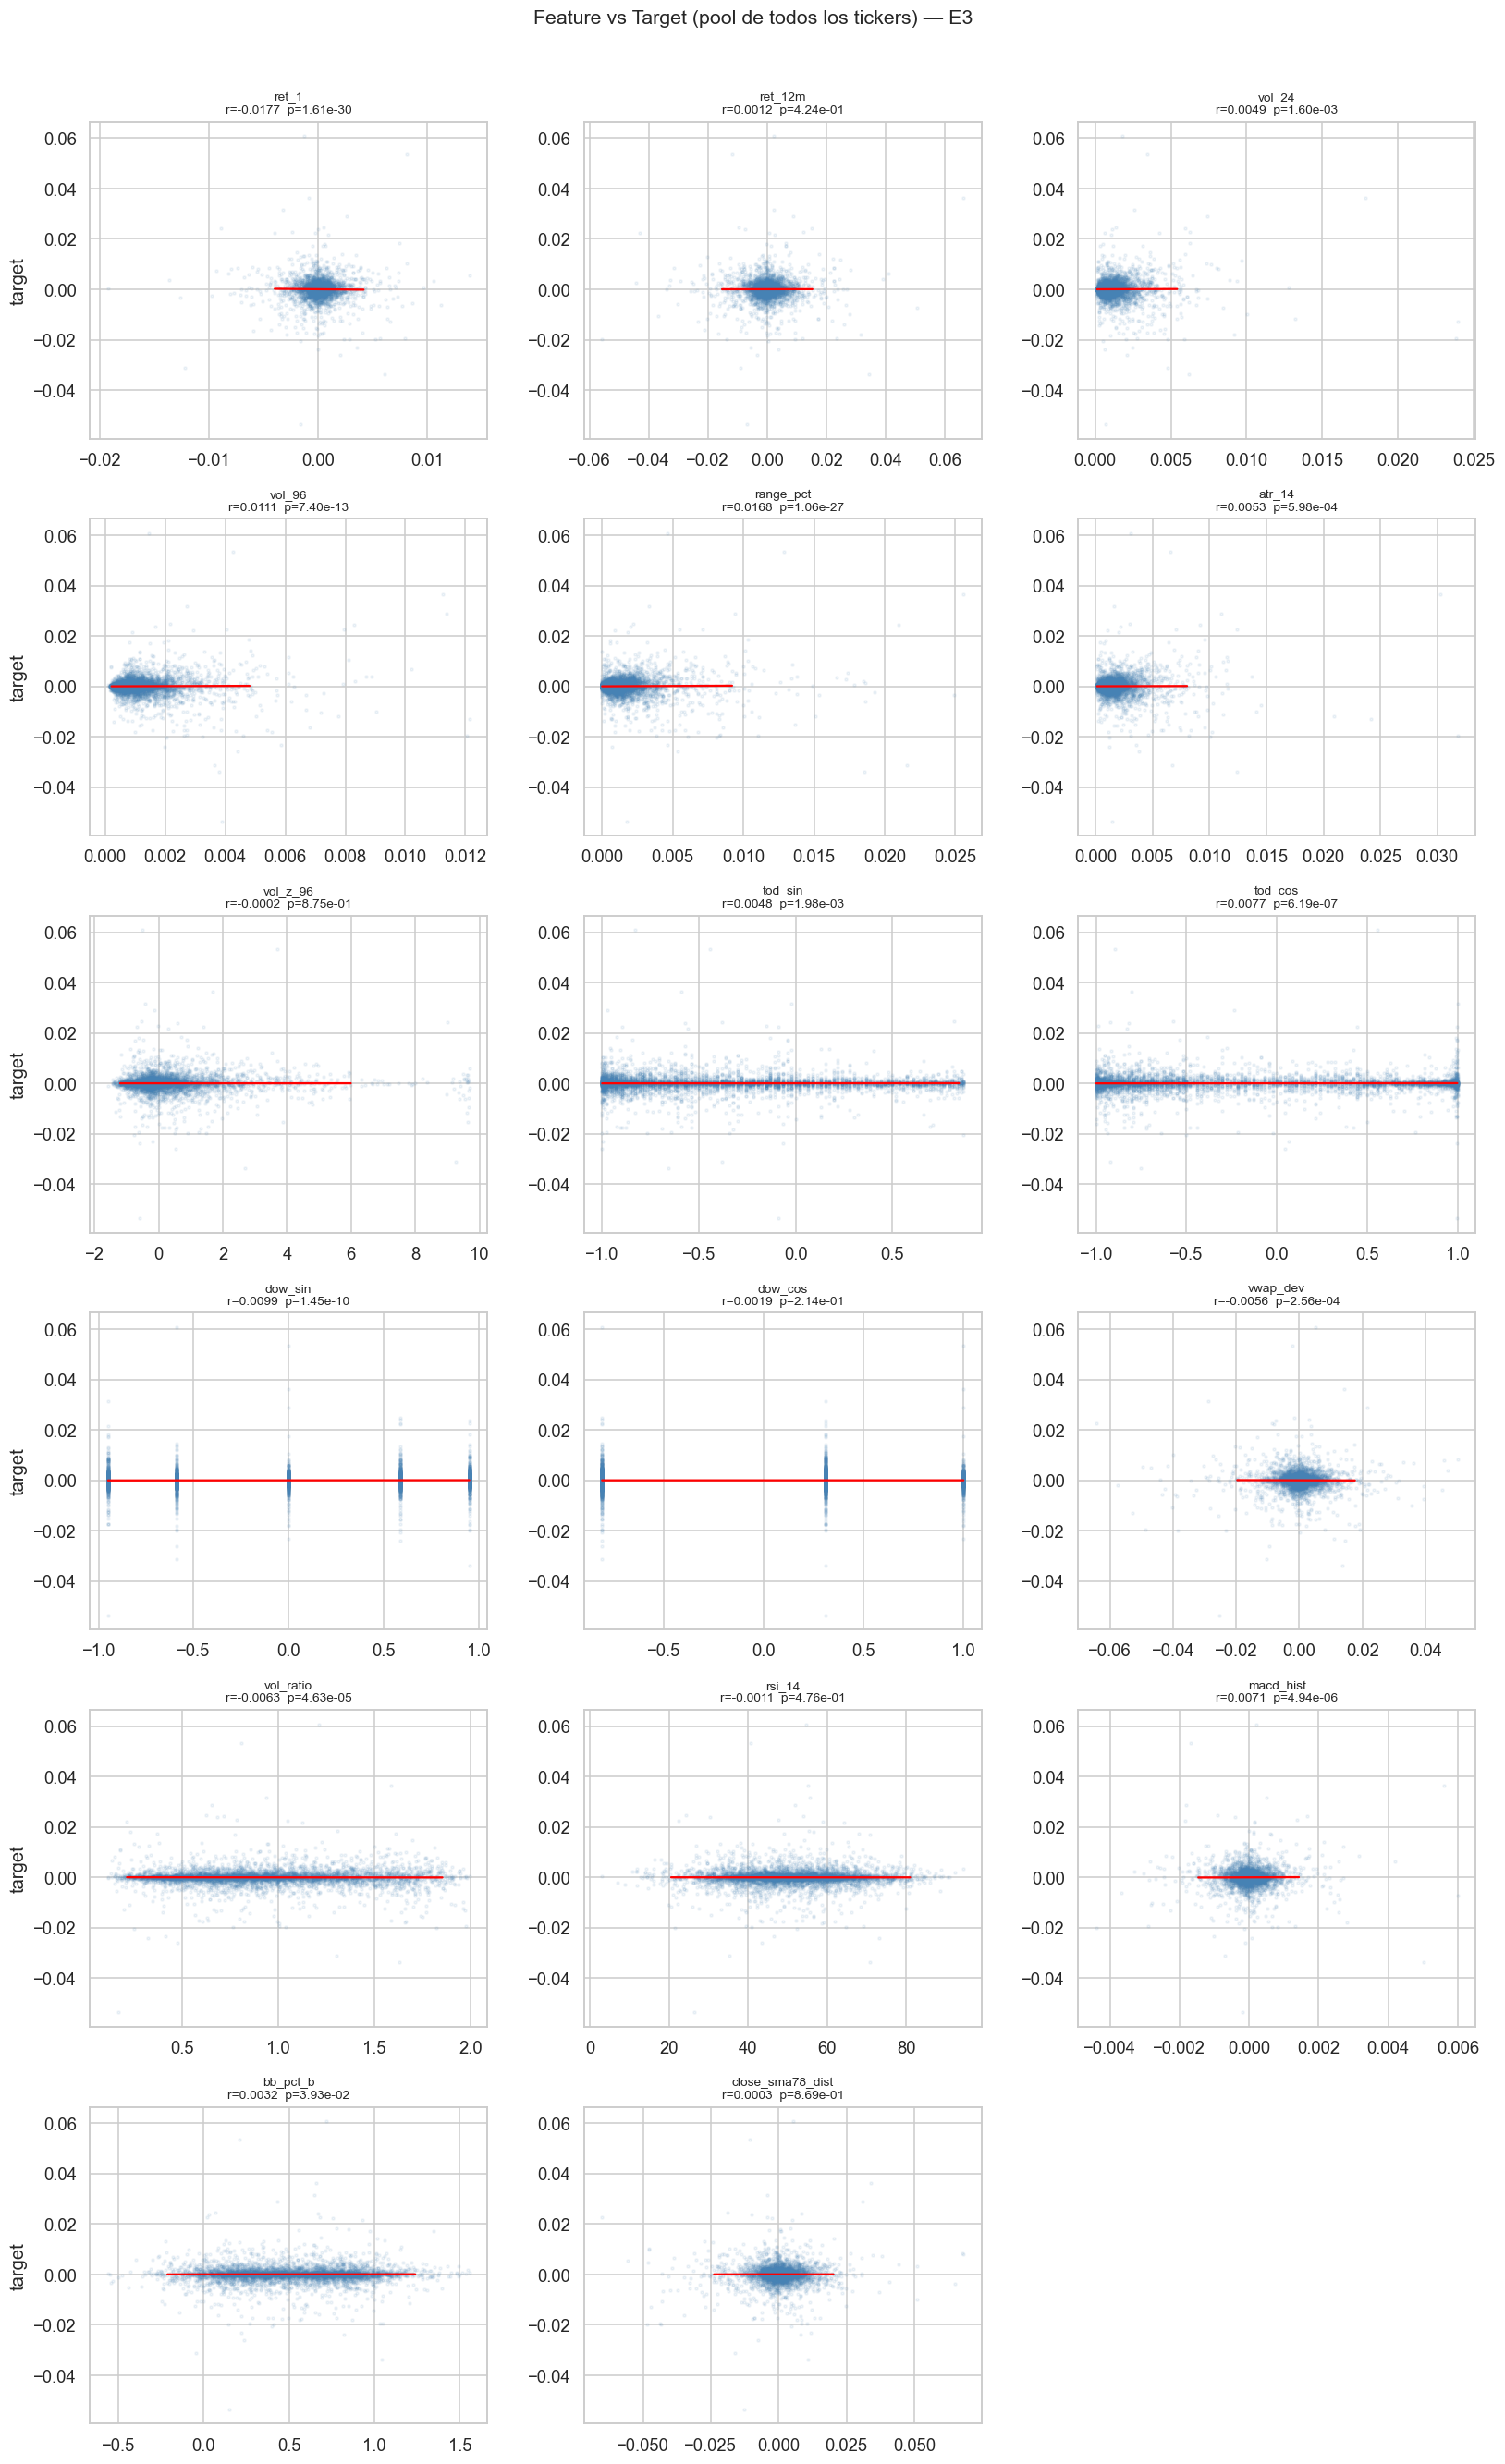

In [21]:
# --- Scatter plots: feature vs target with Pearson r + p-value ---
# Pool of every ticker to see the global relationship.
# Subsample for the visualization (5K points), statistics on the full data.

target_col = f"target_ret_fwd_{HORIZON_BARS}"
pool = pd.concat([combined_all[t] for t in E3_TICKERS if t in combined_all], ignore_index=True)
feat_cols = list(features_all[E3_TICKERS[0]].columns)

n_feats = len(feat_cols)
n_cols = 3
n_rows = (n_feats + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

SUBSAMPLE = 5000
rng = np.random.RandomState(42)
idx_plot = rng.choice(len(pool), size=min(SUBSAMPLE, len(pool)), replace=False)

for i, feat in enumerate(feat_cols):
    ax = axes[i]
    x_full = pool[feat].dropna()
    y_full = pool.loc[x_full.index, target_col].dropna()
    common = x_full.index.intersection(y_full.index)

    # Pearson on the full data
    r, p = stats.pearsonr(pool.loc[common, feat], pool.loc[common, target_col])

    # Subsampled scatter
    x_plot = pool[feat].iloc[idx_plot]
    y_plot = pool[target_col].iloc[idx_plot]
    ax.scatter(x_plot, y_plot, alpha=0.08, s=4, color="steelblue")

    # Regression line on the full data
    z = np.polyfit(pool.loc[common, feat], pool.loc[common, target_col], 1)
    x_line = np.linspace(x_plot.quantile(0.01), x_plot.quantile(0.99), 100)
    ax.plot(x_line, np.polyval(z, x_line), color="red", linewidth=1.5)

    ax.set_title(f"{feat}\nr={r:.4f}  p={p:.2e}", fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("target" if i % n_cols == 0 else "")

# Hide leftover axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Feature vs target (pool of every ticker) — E3", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()


---

## 4. Target analysis (30-min forward return)

The target is `ln(close[t+6] / close[t])` — the log return over 6 bars (30 min).

Unlike E1 (90 days), this target lives on a ~100x smaller scale.
The key question: is there enough signal over the noise for the LSTM to capture it?

### 4.1 Target distribution by ticker


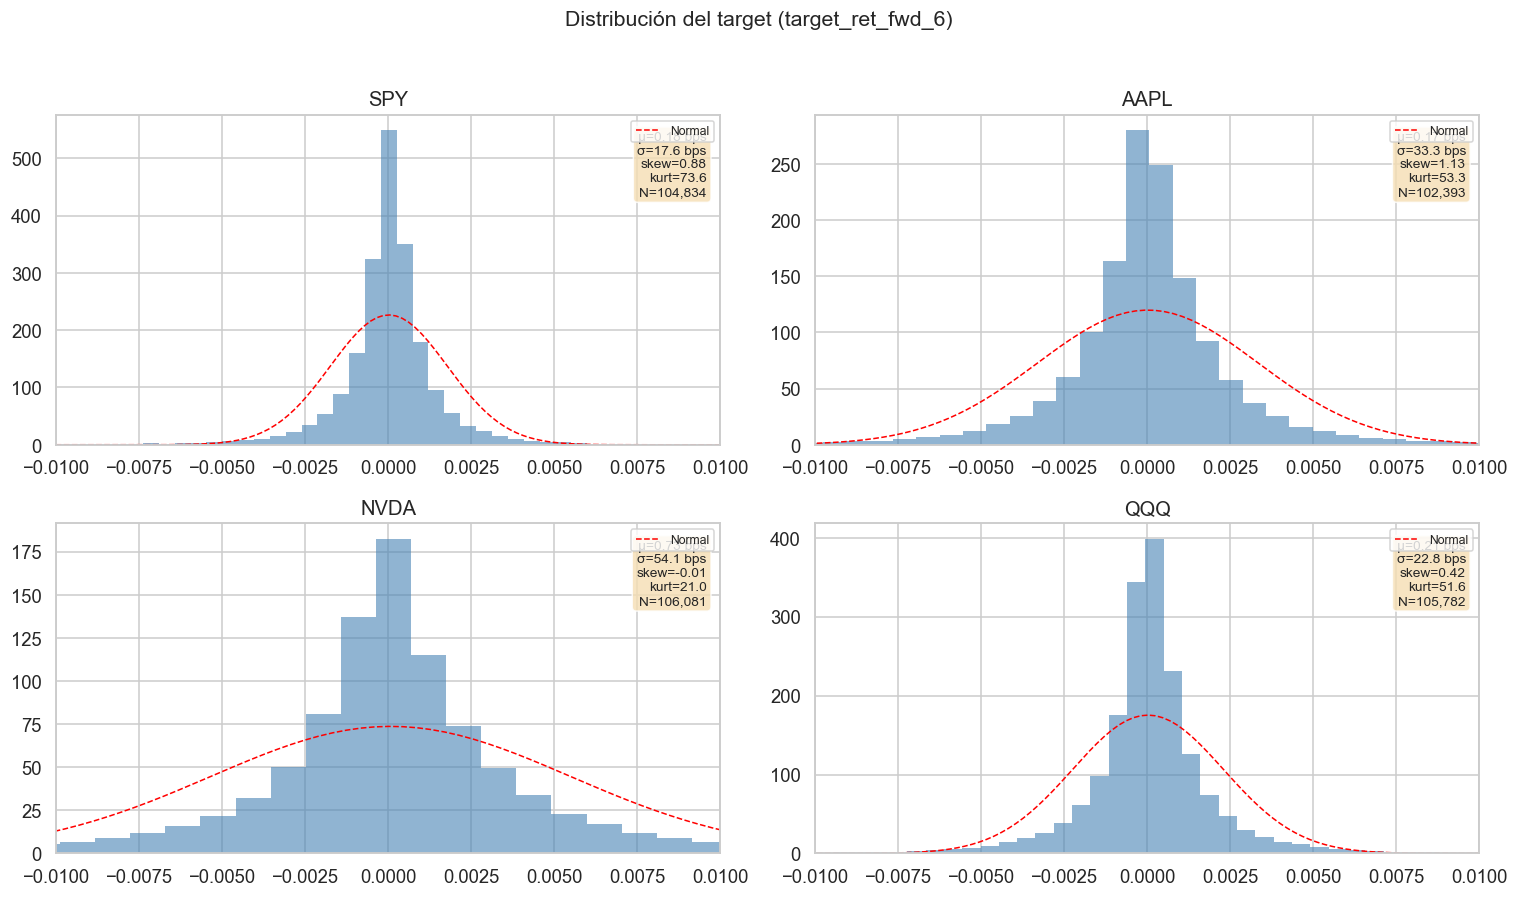

In [22]:
# --- Target distribution (30-min forward return) by ticker ---
target_col = f"target_ret_fwd_{HORIZON_BARS}"

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, ticker in zip(axes.flat, E3_TICKERS):
    if ticker not in targets_all:
        continue
    y = targets_all[ticker].values

    ax.hist(y, bins=200, density=True, alpha=0.6, color="steelblue", edgecolor="none")

    # Normal fit
    mu, sigma = y.mean(), y.std()
    x_range = np.linspace(y.min(), y.max(), 500)
    ax.plot(x_range, stats.norm.pdf(x_range, mu, sigma), "--", color="red", linewidth=1, label="Normal")

    kurt = stats.kurtosis(y, fisher=True)
    skew_ = stats.skew(y)
    ax.text(0.98, 0.95,
            f"μ={mu*1e4:.2f} bps\nσ={sigma*1e4:.1f} bps\nskew={skew_:.2f}\nkurt={kurt:.1f}\nN={len(y):,}",
            transform=ax.transAxes, va="top", ha="right", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))
    ax.set_title(f"{ticker}")
    ax.set_xlim(-0.01, 0.01)
    ax.legend(fontsize=8)

fig.suptitle(f"Target distribution ({target_col})", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


### 4.2 Target autocorrelation (ACF)

The target's autocorrelation is critical: if the ACF decays fast, each sample is almost independent and the LSTM has little to "remember". If it persists, there are exploitable temporal patterns.


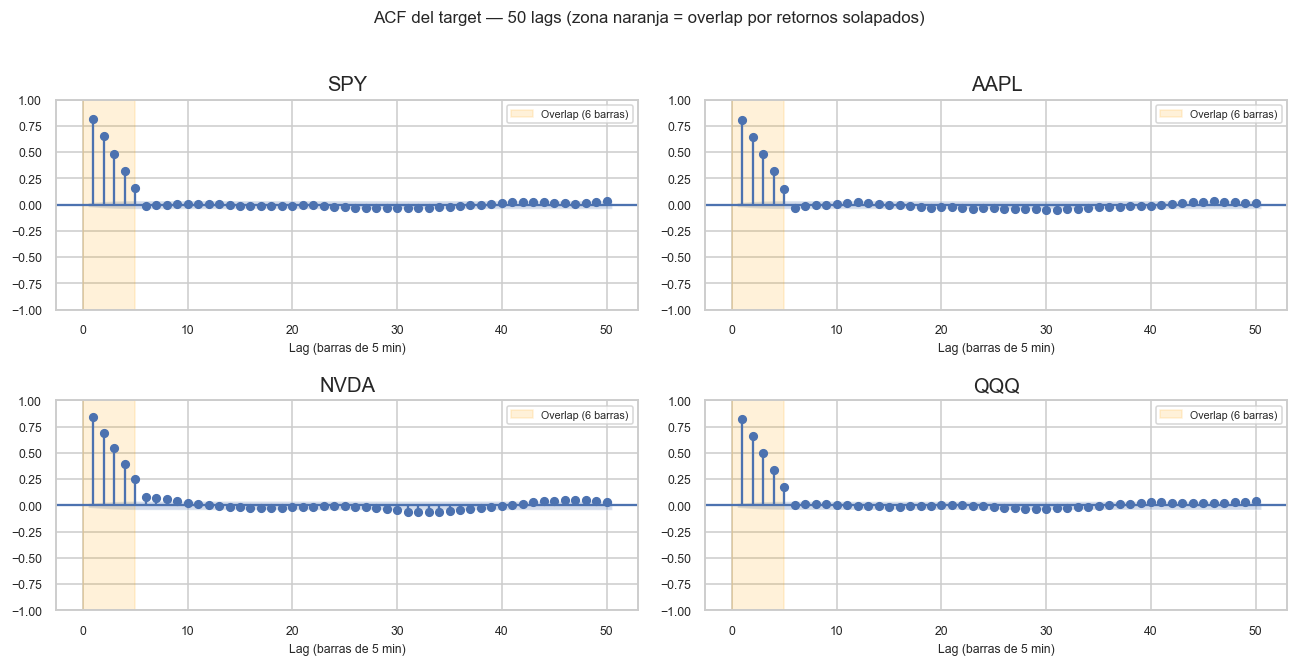

In [23]:

# --- ACF of the target (30-min forward return) ---
# 50 lags = ~4 hours of trading, enough to see the overlap (lags 1-5)
# and any significant autocorrelation beyond it.
# Subsample to 10K points to avoid O(n x lags) with ~100K bars.

from statsmodels.graphics.tsaplots import plot_acf

ACF_LAGS = 50
ACF_SUBSAMPLE = 10_000

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for ax, ticker in zip(axes.flat, E3_TICKERS):
    if ticker not in targets_all:
        continue
    series = targets_all[ticker].values
    if len(series) > ACF_SUBSAMPLE:
        series = series[:ACF_SUBSAMPLE]
    plot_acf(series, lags=ACF_LAGS, ax=ax, alpha=0.05,
             title=f"{ticker}", zero=False)
    ax.set_xlabel("Lag (5-min bars)", fontsize=8)
    ax.axvspan(0, HORIZON_BARS - 1, alpha=0.15, color="orange",
               label=f"Overlap ({HORIZON_BARS} bars)")
    ax.legend(fontsize=7, loc="upper right")
    ax.tick_params(labelsize=8)

fig.suptitle("Target ACF — 50 lags (orange zone = overlap from overlapping returns)",
             fontsize=11, y=1.01)
fig.tight_layout()
plt.show()


### 4.3 Rolling mean and std of the target

Useful for spotting volatility regimes and regime changes in the target over time.


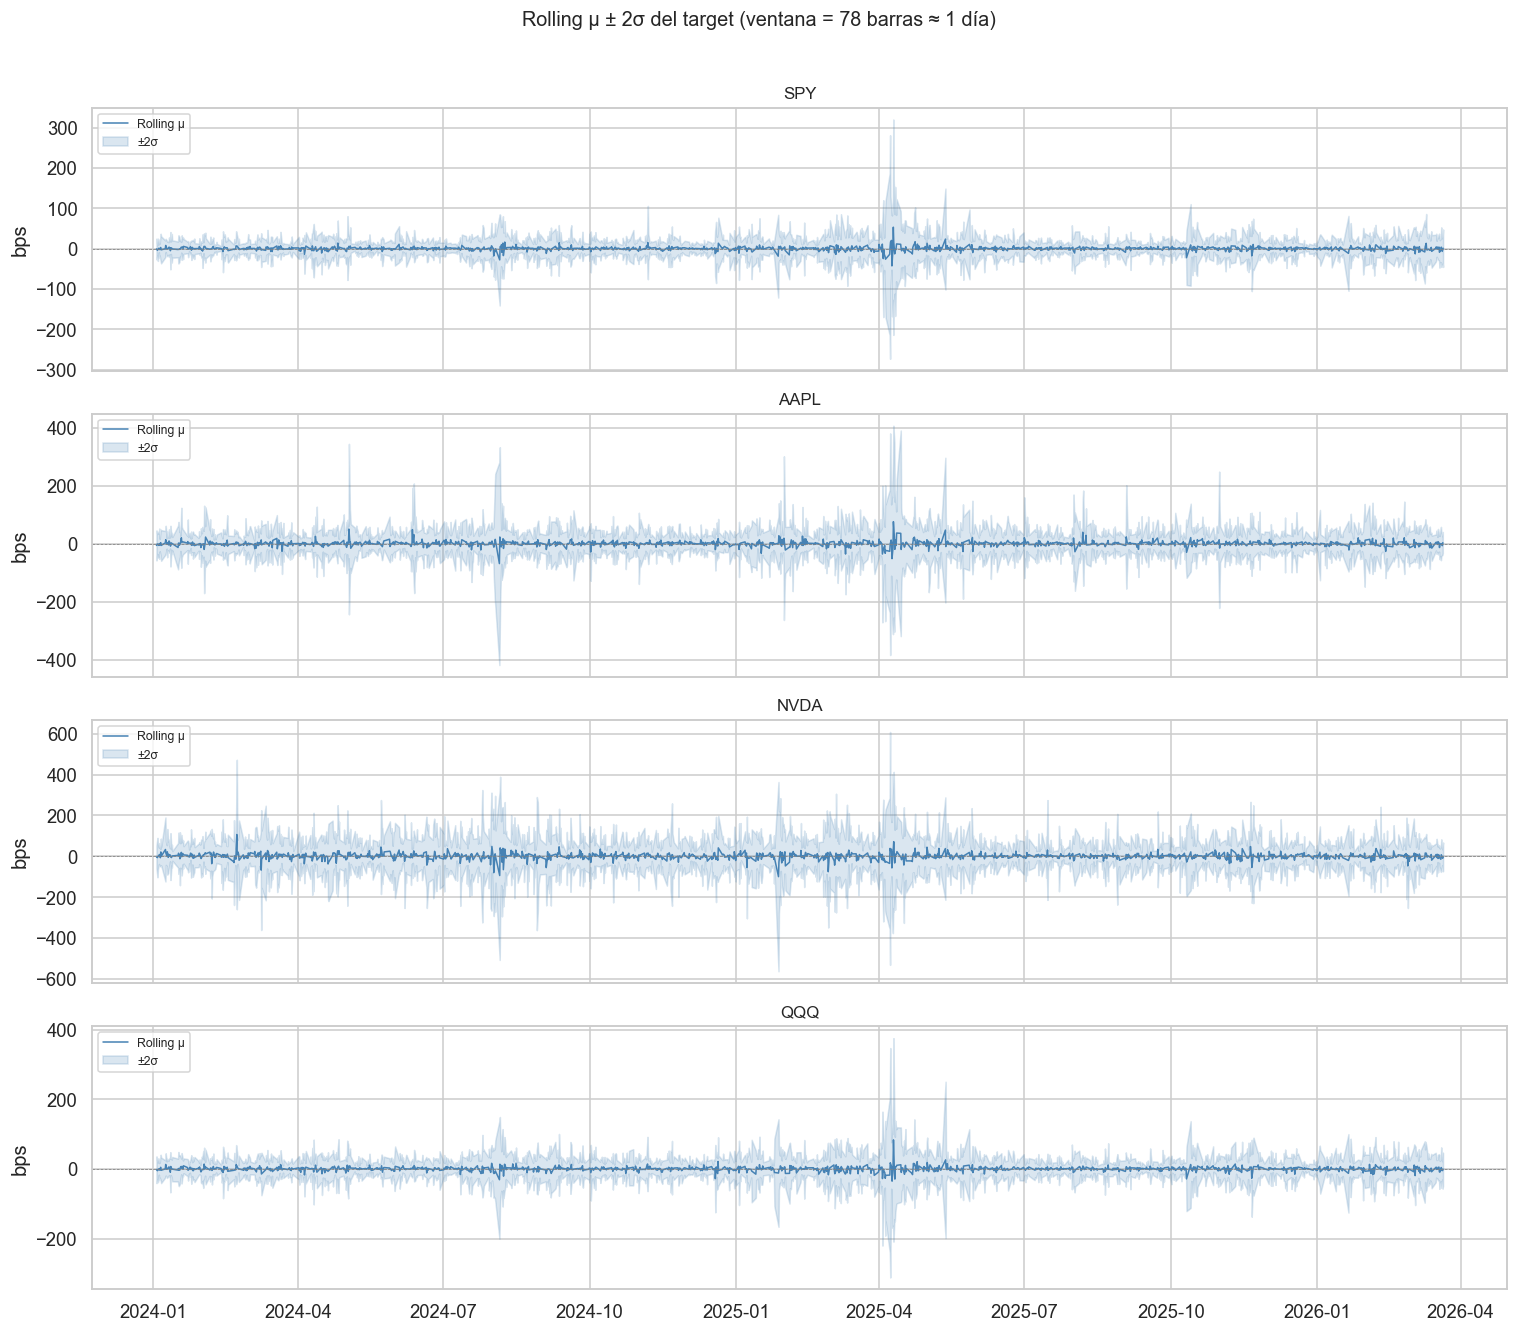

In [24]:
# --- Rolling mean and std of the target (window = 1 day = 78 bars) ---
# We subsample to daily resolution so the chart stays readable
ROLL_WINDOW = BARS_PER_TRADING_DAY  # 78 bars = 1 day

fig, axes = plt.subplots(len(E3_TICKERS), 1, figsize=(14, 3 * len(E3_TICKERS)), sharex=True)
if len(E3_TICKERS) == 1:
    axes = [axes]

for ax, ticker in zip(axes, E3_TICKERS):
    if ticker not in targets_all:
        continue
    y = targets_all[ticker]
    roll_mean = y.rolling(ROLL_WINDOW).mean().iloc[::ROLL_WINDOW]   # daily subsample
    roll_std = y.rolling(ROLL_WINDOW).std().iloc[::ROLL_WINDOW]

    ax.plot(roll_mean.index, roll_mean.values * 1e4, color="steelblue", linewidth=1, label="Rolling μ")
    ax.fill_between(
        roll_std.index,
        (roll_mean.values - 2 * roll_std.values) * 1e4,
        (roll_mean.values + 2 * roll_std.values) * 1e4,
        alpha=0.2, color="steelblue", label="±2σ",
    )
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.set_ylabel("bps")
    ax.set_title(f"{ticker}", fontsize=11)
    ax.legend(fontsize=8, loc="upper left")

fig.suptitle(f"Rolling μ ± 2σ of the target (window = {ROLL_WINDOW} bars ~ 1 day)", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()


---

## 5. Signal vs noise and trading viability

### 5.1 What fraction of the target beats the transaction cost?

The round-trip cost is 20 bps. For a prediction to be profitable, the predicted return has to clear that threshold. What fraction of the target does?


In [25]:
# --- Fraction of the target that beats the transaction cost ---
# If only 5% of the bars have |target| > 20 bps, the model needs to be
# very selective (trade rarely) to be profitable.

cost_threshold = ROUND_TRIP_BPS / 1e4  # 20 bps -> 0.002

print(f"Round-trip cost: {ROUND_TRIP_BPS} bps ({cost_threshold:.4f})")
print(f"{'Ticker':<10} {'|target|>cost':>15} {'target>+cost':>15} {'target<-cost':>15} {'|target| μ (bps)':>15}")
print("-" * 75)

for ticker in E3_TICKERS:
    if ticker not in targets_all:
        continue
    y = targets_all[ticker].values
    frac_exceeds = np.mean(np.abs(y) > cost_threshold)
    frac_long = np.mean(y > cost_threshold)
    frac_short = np.mean(y < -cost_threshold)
    mean_abs = np.mean(np.abs(y)) * 1e4

    print(f"{ticker:<10} {frac_exceeds:>14.1%} {frac_long:>14.1%} {frac_short:>14.1%} {mean_abs:>14.1f}")

print(f"\n→ The model has to be selective: only trade when the signal is strong.")


Costo round-trip: 20 bps (0.0020)
Ticker      |target|>costo   target>+costo   target<-costo |target| μ (bps)
---------------------------------------------------------------------------
SPY                 12.5%           6.2%           6.4%            9.9
AAPL                29.0%          14.7%          14.3%           18.7
NVDA                46.7%          24.5%          22.3%           32.2
QQQ                 19.2%           9.7%           9.5%           13.1

→ El modelo debe ser selectivo: operar solo cuando la señal es fuerte.


### 5.2 Target distribution by hour of day

Does the "exploitable signal" concentrate in certain hours? If the target is more volatile at the open, the model could learn to trade more during those hours.


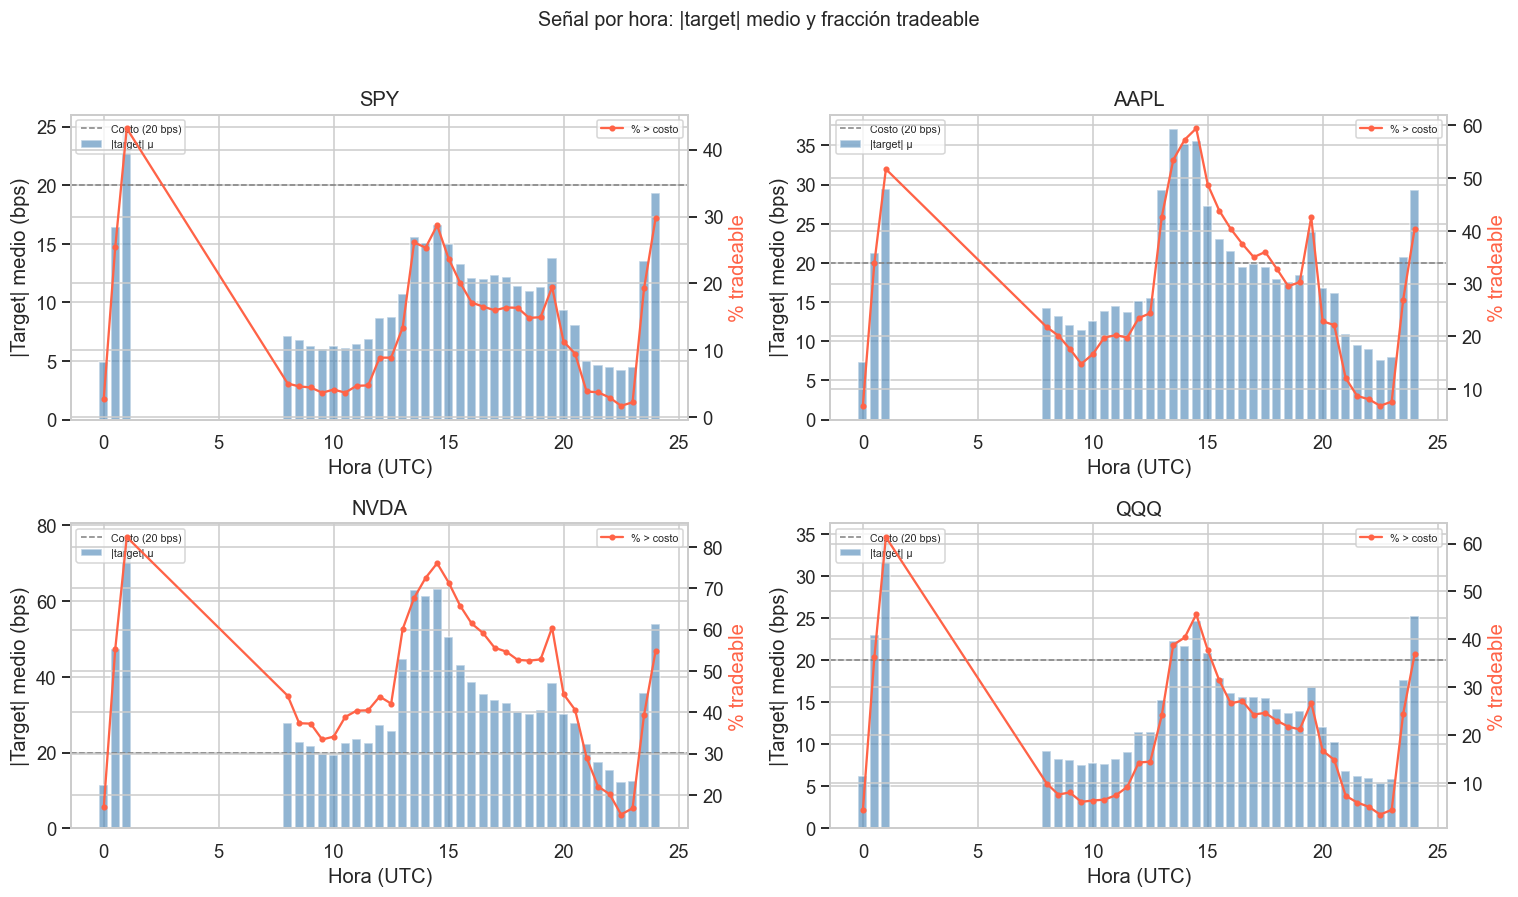

In [26]:
# --- Average |target| and % beating the cost, by hour of day ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, ticker in zip(axes.flat, E3_TICKERS):
    if ticker not in combined_all:
        continue
    df_c = combined_all[ticker].copy()
    target_col = f"target_ret_fwd_{HORIZON_BARS}"
    df_c["abs_target_bps"] = df_c[target_col].abs() * 1e4
    df_c["hour_bin"] = ((df_c.index.hour + df_c.index.minute / 60) * 2).round() / 2

    hourly = df_c.groupby("hour_bin").agg(
        mean_abs=("abs_target_bps", "mean"),
        frac_tradeable=("abs_target_bps", lambda x: (x > ROUND_TRIP_BPS).mean()),
    )

    ax2 = ax.twinx()
    ax.bar(hourly.index, hourly["mean_abs"], width=0.4, color="steelblue", alpha=0.6, label="|target| μ")
    ax2.plot(hourly.index, hourly["frac_tradeable"] * 100, "o-", color="tomato", markersize=3, label="% > cost")
    ax.axhline(ROUND_TRIP_BPS, color="gray", linewidth=1, linestyle="--", label=f"Cost ({ROUND_TRIP_BPS} bps)")
    ax.set_title(f"{ticker}")
    ax.set_xlabel("Hour (UTC)")
    ax.set_ylabel("Mean |target| (bps)")
    ax2.set_ylabel("% tradeable", color="tomato")
    ax.legend(fontsize=7, loc="upper left")
    ax2.legend(fontsize=7, loc="upper right")

fig.suptitle("Signal by hour: mean |target| and tradeable fraction", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()


---

## 6. Summary statistics table


In [27]:
# --- Summary table per ticker: returns, target, features ---
target_col = f"target_ret_fwd_{HORIZON_BARS}"
cost_threshold = ROUND_TRIP_BPS / 1e4

rows = []
for ticker in E3_TICKERS:
    if ticker not in data:
        continue
    df_t = data[ticker]
    close = df_t["close"]
    ret = np.log(close / close.shift(1)).dropna()
    y = targets_all[ticker].values

    rows.append({
        "Ticker": ticker,
        "Bars": f"{len(df_t):,}",
        "Valid samples": f"{len(targets_all[ticker]):,}",
        "Ret 5m μ (bps)": f"{ret.mean() * 1e4:.3f}",
        "Ret 5m σ (bps)": f"{ret.std() * 1e4:.1f}",
        "Ret 5m kurt": f"{stats.kurtosis(ret, fisher=True):.1f}",
        "Target μ (bps)": f"{y.mean() * 1e4:.3f}",
        "Target σ (bps)": f"{y.std() * 1e4:.1f}",
        "Target kurt": f"{stats.kurtosis(y, fisher=True):.1f}",
        f"|Target|>{ROUND_TRIP_BPS}bps": f"{np.mean(np.abs(y) > cost_threshold):.1%}",
    })

stats_df = pd.DataFrame(rows)
stats_df.style.set_caption("Summary statistics per ticker — E3 Intraday")


,Ticker,Barras,Muestras válidas,Ret 5m μ (bps),Ret 5m σ (bps),Ret 5m kurt,Target μ (bps),Target σ (bps),Target kurt,|Target|>20bps
0,SPY,"104,936","104,834",0.030,7.3,221.9,0.185,17.6,73.6,12.5%
1,AAPL,"102,495","102,393",0.027,14.2,166.6,0.170,33.3,53.3,29.0%
2,NVDA,"106,183","106,081",0.119,22.9,95.8,0.730,54.1,21.0,46.7%
3,QQQ,"105,884","105,782",0.034,9.6,196.8,0.212,22.8,51.6,19.2%


### 6.1 Cross-ticker heatmap: mean of each feature


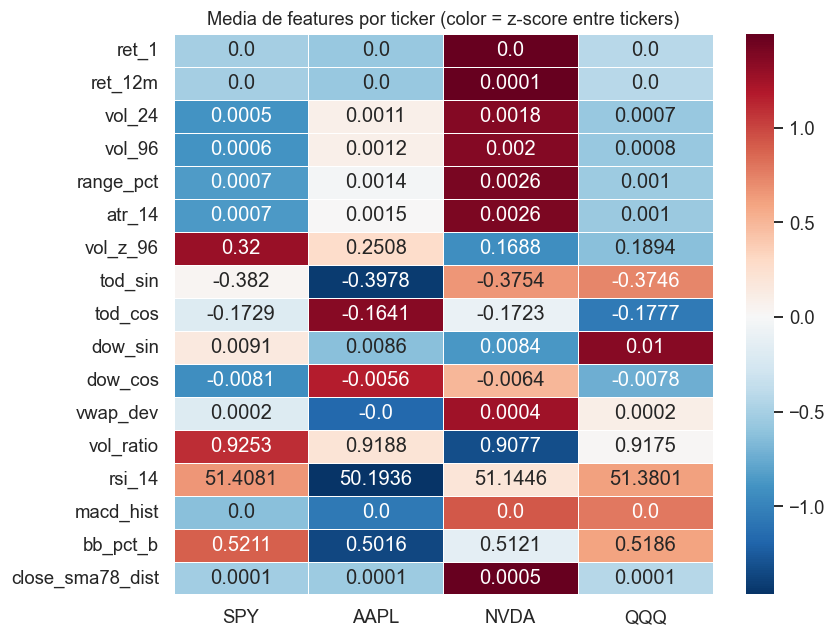

In [28]:
# --- Cross-ticker heatmap: mean of each feature ---
# Reveals structural differences between tickers (e.g. NVDA being more volatile)
feat_cols = list(features_all[E3_TICKERS[0]].columns)

mean_matrix = pd.DataFrame(index=feat_cols, columns=E3_TICKERS, dtype=float)
for ticker in E3_TICKERS:
    if ticker not in features_all:
        continue
    for feat in feat_cols:
        mean_matrix.loc[feat, ticker] = features_all[ticker][feat].mean()

fig, ax = plt.subplots(figsize=(8, 6))
# Normalize per feature (row-wise z-score) so they become comparable
mean_z = mean_matrix.astype(float).apply(lambda row: (row - row.mean()) / (row.std() + 1e-12), axis=1)
sns.heatmap(mean_z, annot=mean_matrix.astype(float).round(4), fmt="", cmap="RdBu_r",
            center=0, ax=ax, linewidths=0.5)
ax.set_title("Feature means by ticker (color = z-score across tickers)", fontsize=12)
fig.tight_layout()
plt.show()


---
## 7. EDA Conclusions

### 7.1 Non-normal distributions and fat tails

1. **5-min returns are strongly non-normal**
   - The Q-Q plots and Jarque-Bera tests reject normality on every ticker. Kurtosis is even higher than on daily data (E1/E2).
   - This reinforces the choice of a Huber loss and a non-linear model (LSTM) able to capture non-linear relationships.

2. **Extreme concentration around zero**
   - The vast majority of 5-min returns sit within ±5 bps, which sets a minimum signal floor for the model to be profitable.

### 7.2 Intraday seasonality

1. **U-shape pattern in volume and volatility**
   - High activity at the open (13:30-14:30 UTC) and close (19:00-20:00 UTC), with a minimum at midday.
   - The cyclical features `tod_sin`/`tod_cos` capture this temporal structure.

2. **Mean return by hour is not significantly different from zero**
   - There is no consistent "golden hour" to trade — the exploitable signal has to come from the technical features, not from the clock.

### 7.3 Features and multicollinearity

1. **9 technical features designed for high frequency**
   - `vol_24` and `vol_96` capture volatility at two scales; `atr_14` adds true range; `vol_z_96` normalizes relative volatility.
   - Highly correlated pairs (if any) are candidates for reduction to avoid redundancy.

2. **Feature-target correlations are very low**
   - That is expected on intraday data: the signal-to-noise ratio is much lower than on daily data.
   - The model has to combine multiple weak features to extract signal — a classic case for deep learning.

### 7.4 Signal vs noise: trading viability

1. **Exploitable fraction of the target**
   - Only a small fraction of the bars beats the transaction cost (20 bps round-trip).
   - The model has to be highly selective: avoiding losing trades matters more than maximizing winning ones.

2. **Implication for the architecture**
   - The 3-LSTM ensemble helps filter noise: only trade when the 3 members agree.
   - Evaluating by profit factor and Sharpe is more relevant than RMSE/MAE for this strategy.

### 7.5 Differences between tickers

1. **SPY and QQQ** (ETFs): higher liquidity, tighter spread, more concentrated return distributions. They are the "cleanest" to model.
2. **AAPL and NVDA** (individual stocks): higher idiosyncratic volatility, potentially more signal but also more noise.
3. **Every ticker is US-listed**: there is no market segmentation as in E1/E2 (AR vs US). Per-ticker Z-score normalization still matters because of scale differences.

### 7.6 Modelling recommendations

- Keep the current 9-indicator feature set. Consider dropping multicollinear pairs if |r| > 0.85 proves consistent.
- Keep per-ticker Z-score normalization for features and target.
- Prioritize trading metrics (Sharpe, profit factor, directional accuracy) over regression metrics (MAE, RMSE).
- Consider walk-forward CV with an embargo >= 6 bars (30 min) instead of the current simple time split.
- Monitor the exploitable signal fraction as a model health metric.
